# CYGNSS Streamflow Modeling for Ungauged Basins (CSMUB)

## Feedforward Neural Network (FNN) Model

### About

This code

---


Author(s): Anna Valcarcel

Date of Creation: November 15, 2024

Last Updated: November 11, 2025

Version History:
*   v1.00:06 - Creating FNN architecture and running model. Modulating architecture and input parameters.
*   v1.07:09 - Added additional input parameters including land cover classification, soil texture, and terrain slope.

*   v2.00 - Re-running with new subset of all basins (605) after making delineation changes (see `CSMUB_v2_00`). 

## Importing Packages

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report

from tensorflow.python import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K
from keras import initializers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN , Input, Flatten, LSTM, LeakyReLU
from tensorflow.keras import optimizers
from tensorflow.keras.optimizers import SGD, RMSprop, Nadam, Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

## Define Filepaths and Open Station Masterfile


In [4]:
opened = []

masterlist = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/ALL_STATIONS_ALL_MONTHS_COMBINED.csv'

# Load the master list of stations
total_df = pd.read_csv(masterlist)

In [5]:
total_df = total_df[total_df['Q'] != -999]
print(f"Remaining rows: {len(total_df)}")

Remaining rows: 28486


In [6]:
print("Loaded ", len(total_df['grdc_no'].unique()), " stations.")

Loaded  564  stations.


## Save Subset for Training

In [7]:
print(total_df.columns)

Index(['Date', 'grdc_no', 'river', 'station', 'country', 'lat', 'long', 'area',
       'area_delin', 'altitude', 'Q', 'SWE', 'SWE_scaled', 'r2', 'P',
       'avg_slope', 'max_slope', 'LC_1', 'LC_2', 'LC_3', 'LC_4', 'LC_5',
       'LC_6', 'LC_7', 'LC_8', 'LC_9', 'LC_10', 'LC_11', 'LC_12', 'LC_13',
       'LC_14', 'LC_15', 'LC_16', 'LC_17', 'LC_18', 'LC_19', 'LC_20', 'ST_1',
       'ST_2', 'ST_3', 'ST_4', 'ST_5', 'ST_6', 'ST_7', 'ST_8', 'ST_9', 'ST_10',
       'ST_11', 'ST_12', 'ST_13', 'ST_14', 'ST_15', 'ST_16'],
      dtype='object')


In [8]:
training_df = total_df.drop(['Date', 'grdc_no', 'river', 'station', 'country', 'long', 'area',
       'altitude', 'Q', 'SWE','r2',], axis=1)
test_df = total_df['Q']

print(training_df.columns)
print(test_df)

Index(['lat', 'area_delin', 'SWE_scaled', 'P', 'avg_slope', 'max_slope',
       'LC_1', 'LC_2', 'LC_3', 'LC_4', 'LC_5', 'LC_6', 'LC_7', 'LC_8', 'LC_9',
       'LC_10', 'LC_11', 'LC_12', 'LC_13', 'LC_14', 'LC_15', 'LC_16', 'LC_17',
       'LC_18', 'LC_19', 'LC_20', 'ST_1', 'ST_2', 'ST_3', 'ST_4', 'ST_5',
       'ST_6', 'ST_7', 'ST_8', 'ST_9', 'ST_10', 'ST_11', 'ST_12', 'ST_13',
       'ST_14', 'ST_15', 'ST_16'],
      dtype='object')
0          11.533
1          10.474
2          10.060
3          13.697
4          32.535
           ...   
31205    6600.591
31206    4727.504
31207    2541.807
31213    1888.846
31214    3080.021
Name: Q, Length: 28486, dtype: float64


In [9]:
# ----------------------------
# Preserve metadata (NOT for training)
# ----------------------------
metadata = total_df[['Date', 'grdc_no']].copy()

In [10]:
# ----------------------------
# Create feature matrix and target
# ----------------------------
X_df = total_df.drop(
    columns=[
        'Date', 'grdc_no', 'river', 'station', 'country',
        'long', 'area', 'altitude',
        'Q', 'SWE', 'r2'
    ]
)

y_df = total_df['Q']

print(X_df.columns)

X = X_df.to_numpy()
y = y_df.to_numpy()

Index(['lat', 'area_delin', 'SWE_scaled', 'P', 'avg_slope', 'max_slope',
       'LC_1', 'LC_2', 'LC_3', 'LC_4', 'LC_5', 'LC_6', 'LC_7', 'LC_8', 'LC_9',
       'LC_10', 'LC_11', 'LC_12', 'LC_13', 'LC_14', 'LC_15', 'LC_16', 'LC_17',
       'LC_18', 'LC_19', 'LC_20', 'ST_1', 'ST_2', 'ST_3', 'ST_4', 'ST_5',
       'ST_6', 'ST_7', 'ST_8', 'ST_9', 'ST_10', 'ST_11', 'ST_12', 'ST_13',
       'ST_14', 'ST_15', 'ST_16'],
      dtype='object')


## FNN Setup

In [11]:
# Step 1: Replace zeros with a small value
X[X == 0] = 1e-9

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

In [12]:
X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X_scaled,
    y_scaled,
    metadata,
    test_size=0.2,
    random_state=42
)

## Run FNN

In [13]:
# Define the model
model = Sequential([
    Dense(512, input_dim=42, activation='leaky_relu'),
    # Dense(256, activation='leaky_relu'),
    # Dropout(0.2),
    Dense(128, activation='leaky_relu'),
    Dropout(0.2),
    # Dense(64, activation='leaky_relu'),
    # Dropout(0.2),
    Dense(32, activation='leaky_relu'),
    Dense(1, activation='linear')  # Linear activation for regression
])

# Compile the model
model.compile(optimizer=Nadam(learning_rate=1e-3), loss=Huber(delta=0.1), metrics=['accuracy','mae','mse','r2_score'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=175,  # High epochs with early stopping
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[early_stopping, lr_scheduler]
)

/global/home/users/arvalcarcel/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-12-14 13:59:15.486403: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/175
357/357 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0757 - loss: 4.2579e-04 - mae: 0.0150 - mse: 0.0011 - r2_score: -0.0576 - val_accuracy: 0.0767 - val_loss: 7.6422e-05 - val_mae: 0.0046 - val_mse: 1.7814e-04 - val_r2_score: 0.8406 - learning_rate: 0.0010
Epoch 2/175
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.0776 - loss: 7.7732e-05 - mae: 0.0051 - mse: 2.1373e-04 - r2_score: 0.8243 - val_accuracy: 0.0767 - val_loss: 5.5656e-05 - val_mae: 0.0033 - val_mse: 1.2852e-04 - val_r2_score: 0.8850 - learning_rate: 0.0010
Epoch 3/175
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0746 - loss: 7.2505e-05 - mae: 0.0046 - mse: 1.7635e-04 - r2_score: 0.8268 - val_accuracy: 0.0767 - val_loss: 7.4136e-04 - val_mae: 0.0268 - val_mse: 0.0018 - val_r2_score: -0.6534 - learning_rate: 0.0010
Epoch 4/175
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0754 - loss: 1.4878e-04 - mae: 0.0072 - mse: 4.4192e-04 - r2_score: 0.3559 - val_accuracy: 0.0767 - val_loss: 7.19

## Analyze FNN Results

In [56]:
# Step 7: Evaluate
test_loss = model.evaluate(X_test, y_test)
print(f"Test MAPE: {test_loss}")

# Step 8: Predict
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

y_test_scaled = y_test
y_test = scaler_y.inverse_transform(y_test)

results = meta_test.copy()
results['Q_true'] = y_test.flatten()
results['Q_pred'] = y_pred.flatten()

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0796 - loss: 3.2895e-05 - mae: 0.0019 - mse: 7.0647e-05 - r2_score: 0.9335
Test MAPE: [3.8244772440521047e-05, 0.0766935795545578, 0.001955944113433361, 9.13243493414484e-05, 0.9182971715927124]
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [58]:
def nse(predictions, targets):
    return 1 - (np.sum((targets - predictions) ** 2) / np.sum((targets - np.mean(targets)) ** 2))

nse(y_pred, y_test)

0.9182972105681817

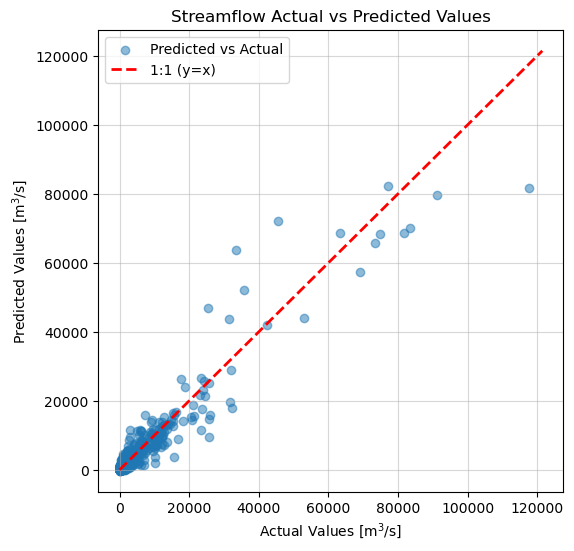

In [59]:
# Step 2: Create the scatter plot
plt.figure(figsize=(6,6))
plt.scatter(results['Q_true'], results['Q_pred'], alpha=0.5, label="Predicted vs Actual")
plt.plot([0, y.max()], [0, y.max()], 'r--', label='1:1 (y=x)', linewidth=2)

# Step 3: Add labels, title, and legend
plt.title("Streamflow Actual vs Predicted Values")
plt.xlabel("Actual Values [m${^3}$/s]")
plt.ylabel("Predicted Values [m${^3}$/s]")
plt.legend()
# plt.xlim(0,25000)
# plt.ylim(0,25000)
plt.grid(alpha=0.5)

# Step 4: Show the plot
plt.show()

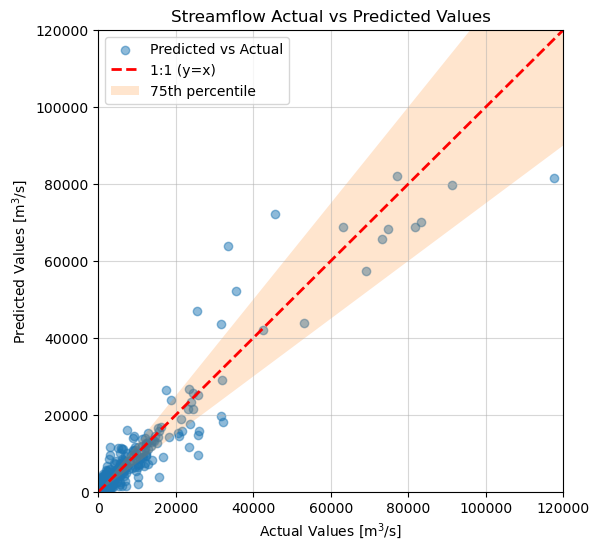

In [60]:
error = 0.25*np.arange(y.min(), y.max(),100)
y_err = np.arange(y.min(), y.max(),100)

# Step 2: Create the scatter plot
plt.figure(figsize=(6,6))
plt.scatter(results['Q_true'], results['Q_pred'], alpha=0.5, label="Predicted vs Actual")
plt.plot([0, y.max()], [0, y.max()], 'r--', label='1:1 (y=x)', linewidth=2)
plt.fill_between(y_err, y_err-error, y_err+error,alpha=0.2,label='75th percentile')

# Step 3: Add labels, title, and legend
plt.title("Streamflow Actual vs Predicted Values")
plt.xlabel("Actual Values [m${^3}$/s]")
plt.ylabel("Predicted Values [m${^3}$/s]")
plt.legend(loc='upper left')
plt.xlim(0,120000)
plt.ylim(0,120000)
plt.grid(alpha=0.5)

# Step 4: Show the plot
plt.show()

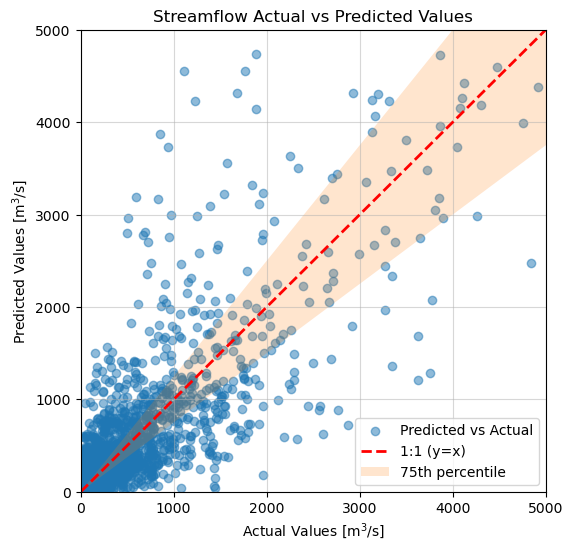

In [62]:
plt.figure(figsize=(6,6))
plt.scatter(results['Q_true'], results['Q_pred'], alpha=0.5, label="Predicted vs Actual")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='1:1 (y=x)', linewidth=2)
plt.fill_between(y_err, y_err-error, y_err+error,alpha=0.2,label='75th percentile')

# Step 3: Add labels, title, and legend
plt.title("Streamflow Actual vs Predicted Values")
plt.xlabel("Actual Values [m${^3}$/s]")
plt.ylabel("Predicted Values [m${^3}$/s]")
plt.legend()
plt.xlim(0,5000)
plt.ylim(0,5000)
plt.grid(alpha=0.5)

# Step 4: Show the plot
plt.show()

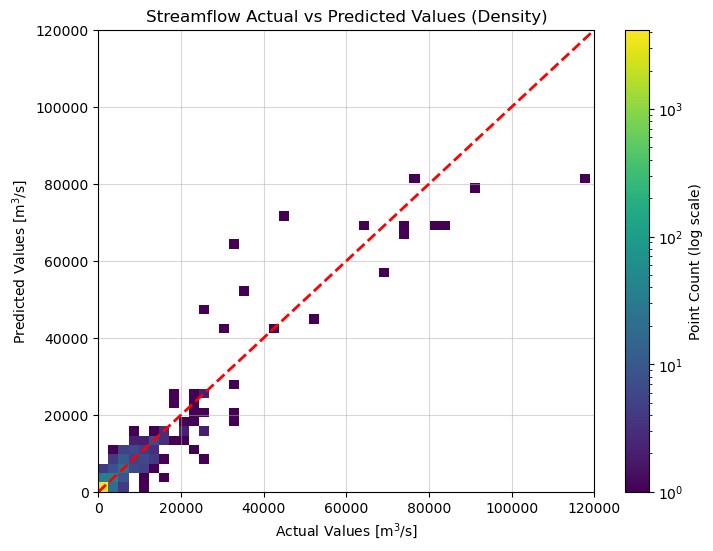

In [63]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(8, 6))

h = plt.hist2d(
    results['Q_true'],
    results['Q_pred'],
    bins=50,
    range=[[0, y.max()], [0, y.max()]],
    norm=LogNorm()     
)

cbar = plt.colorbar(h[3])
cbar.set_label("Point Count (log scale)")

plt.plot([0, y.max()], [0, y.max()], 'r--', linewidth=2)
plt.xlim(0,120000)
plt.ylim(0,120000)
plt.title("Streamflow Actual vs Predicted Values (Density)")
plt.xlabel("Actual Values [m$^3$/s]")
plt.ylabel("Predicted Values [m$^3$/s]")
plt.grid(alpha=0.5)

plt.show()

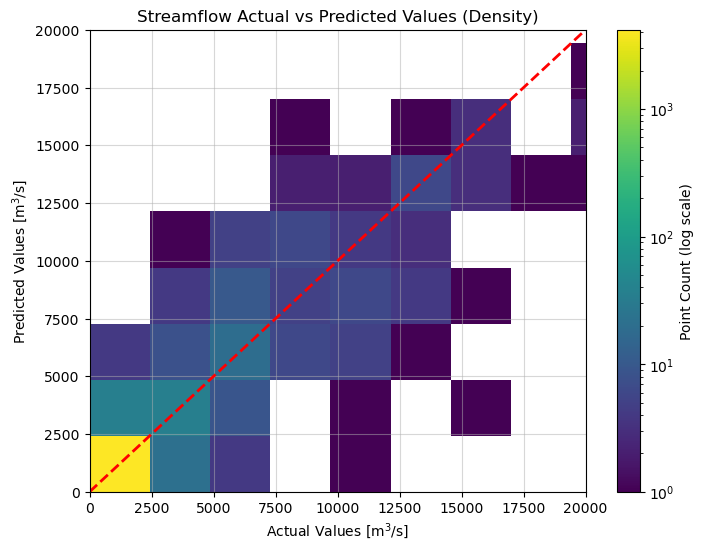

In [64]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(8, 6))

h = plt.hist2d(
    results['Q_true'],
    results['Q_pred'],
    bins=50,
    range=[[0, y.max()], [0, y.max()]],
    norm=LogNorm()     # 🔑 THIS fixes the purple plot
)

cbar = plt.colorbar(h[3])
cbar.set_label("Point Count (log scale)")

plt.plot([0, y.max()], [0, y.max()], 'r--', linewidth=2)
plt.xlim(0,20000)
plt.ylim(0,20000)
plt.title("Streamflow Actual vs Predicted Values (Density)")
plt.xlabel("Actual Values [m$^3$/s]")
plt.ylabel("Predicted Values [m$^3$/s]")
plt.grid(alpha=0.5)

plt.show()


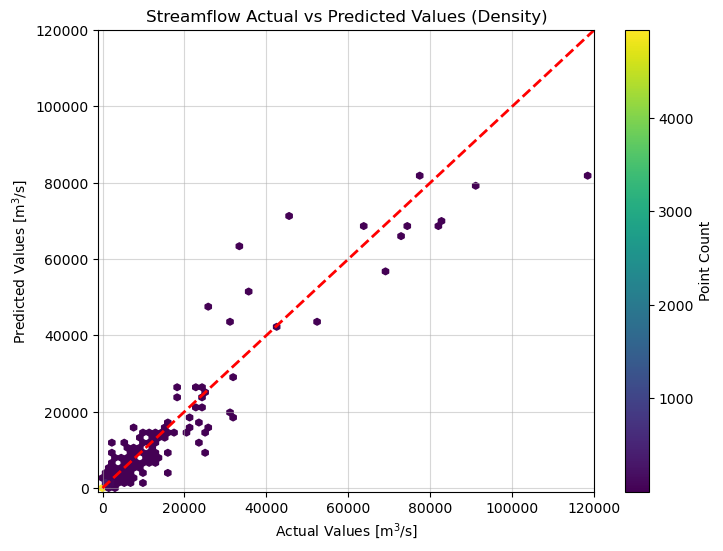

In [65]:
plt.figure(figsize=(8, 6))

hb = plt.hexbin(
    results['Q_true'],
    results['Q_pred'],
    gridsize=80,
    extent=[0, y.max(), 0, y.max()],
    mincnt=1
)

cbar = plt.colorbar(hb)
cbar.set_label("Point Count")

plt.plot([0, y.max()], [0, y.max()], 'r--', linewidth=2)
plt.xlim(-1000,120000)
plt.ylim(-1000,120000)
plt.xlabel("Actual Values [m$^3$/s]")
plt.ylabel("Predicted Values [m$^3$/s]")
plt.title("Streamflow Actual vs Predicted Values (Density)")
plt.grid(alpha=0.5)

plt.show()

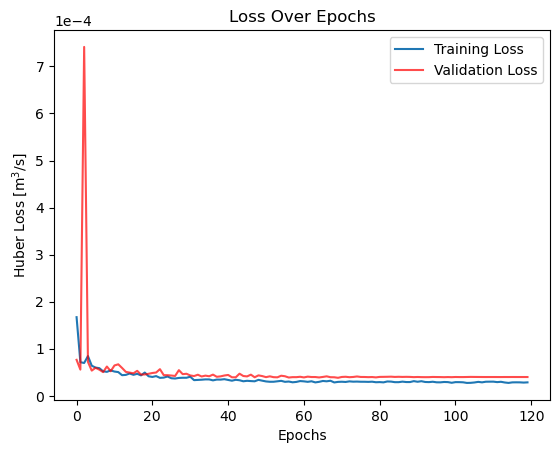

In [66]:
# Plot Loss plt.figure(figsize=(5,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss',color='r',alpha=0.7)
plt.xlabel('Epochs')
plt.ylabel('Huber Loss [m${^3}$/s]')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.title('Loss Over Epochs')
# plt.ylim(0.00001, 0.0002)
plt.legend()
plt.show()

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


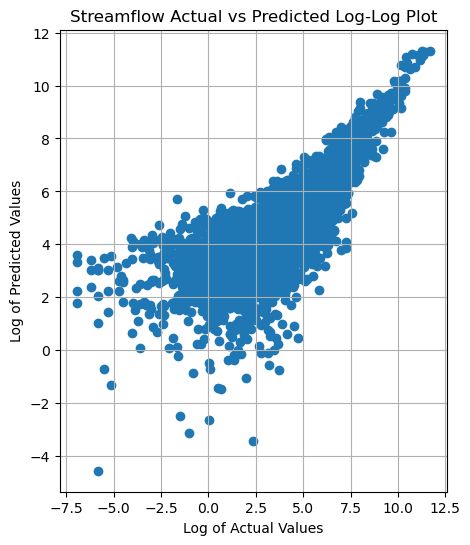

In [67]:
# Create the log-log plot

xlog = np.log(results['Q_true'])
ylog = np.log(results['Q_pred'])

plt.figure(figsize=(5,6))
plt.scatter(xlog, ylog)
# Add labels and title
plt.xlabel('Log of Actual Values')
plt.ylabel('Log of Predicted Values')
plt.title('Streamflow Actual vs Predicted Log-Log Plot')

# Customize gridlines (optional)
plt.grid(True, which="both", ls="-")

# Show the plot
plt.show()

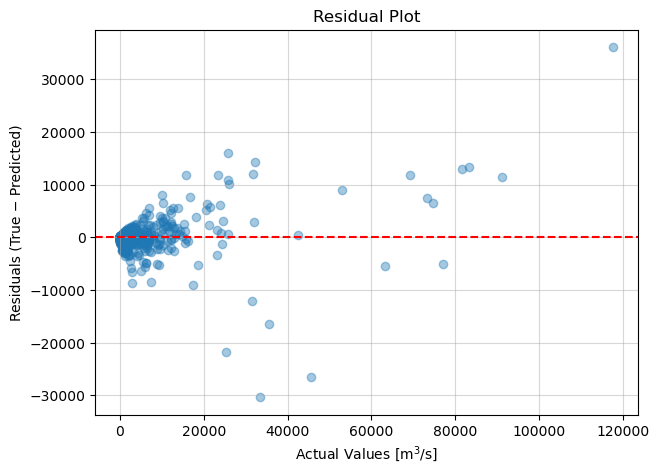

In [68]:
plt.figure(figsize=(7, 5))
residuals = y_test - y_pred
plt.scatter(y_test, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Actual Values [m$^3$/s]")
plt.ylabel("Residuals (True − Predicted)")
plt.title("Residual Plot")
plt.grid(alpha=0.5)

plt.show()

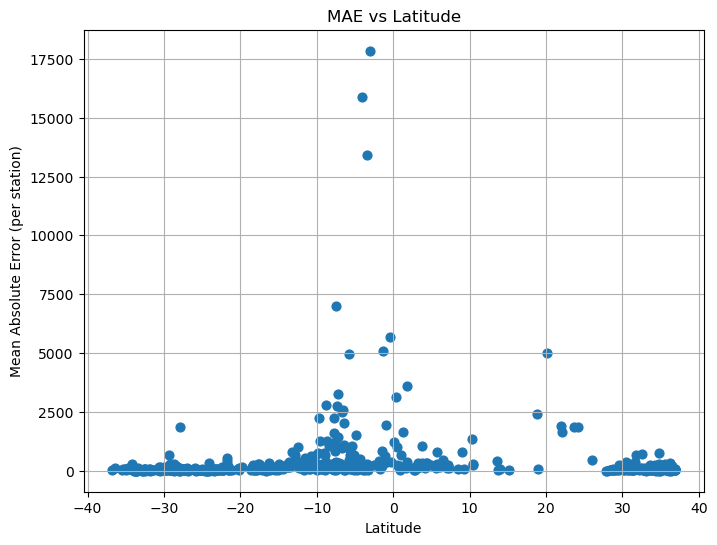

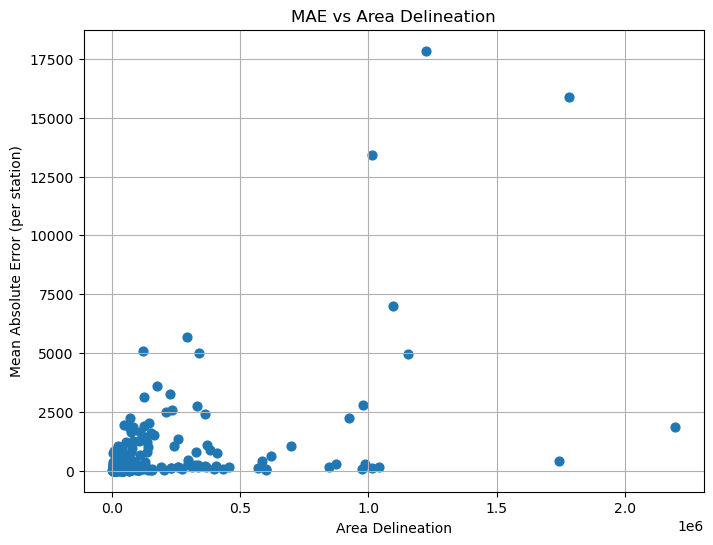

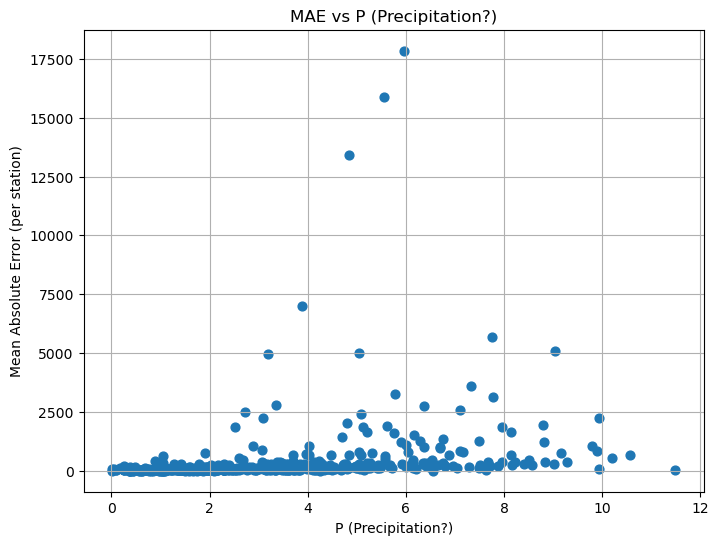

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Make sure y_test_unscaled and y_pred are unscaled
errors = np.abs(y_pred - y_test_unscaled).reshape(-1)

# Add errors and meta-data to a DataFrame
error_df = meta_test.copy()
error_df['error'] = errors

# Include the features you want to plot
X_unscaled = scaler_X.inverse_transform(X_test)
error_df['lat'] = X_unscaled[:, 0]          # column 0
error_df['area_delin'] = X_unscaled[:, 1]   # column 1
error_df['P'] = X_unscaled[:, 3]            # column 3

# Aggregate by station (grdc_no)
station_error = error_df.groupby('grdc_no').agg({
    'error': 'mean',       # mean absolute error per station
    'lat': 'first',        # constant per station
    'area_delin': 'first', # constant per station
    'P': 'mean'            # average P per station
}).reset_index()

# Plot function
def plot_feature_vs_station_error(df, feature_col, feature_name):
    plt.figure(figsize=(8,6))
    plt.scatter(df[feature_col], df['error'], s=40)
    plt.xlabel(feature_name)
    plt.ylabel('Mean Absolute Error (per station)')
    plt.title(f'MAE vs {feature_name}')
    plt.grid(True)
    plt.show()

# Plots
plot_feature_vs_station_error(station_error, 'lat', 'Latitude')
plot_feature_vs_station_error(station_error, 'area_delin', 'Area Delineation')
plot_feature_vs_station_error(station_error, 'P', 'P (Precipitation?)')

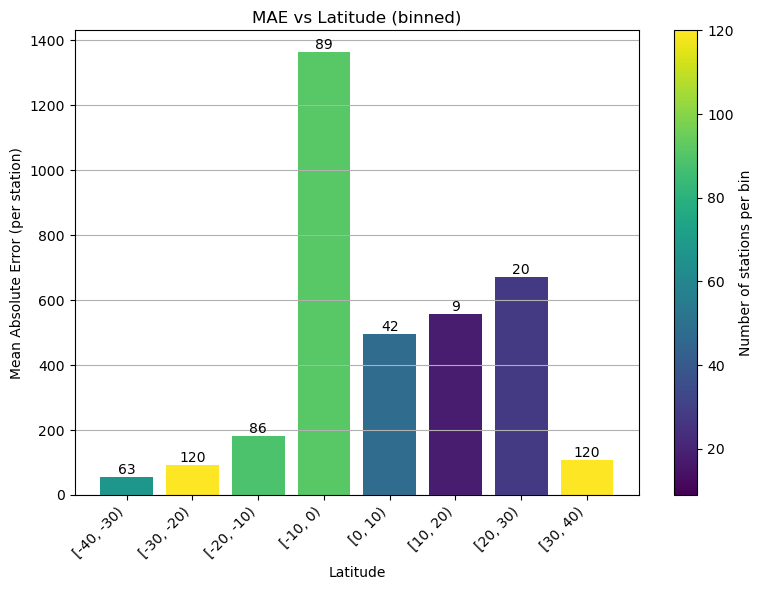

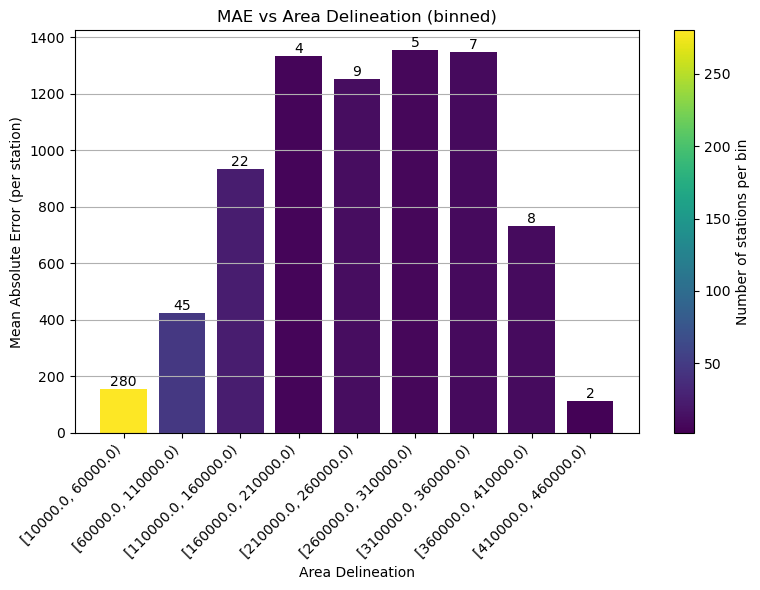

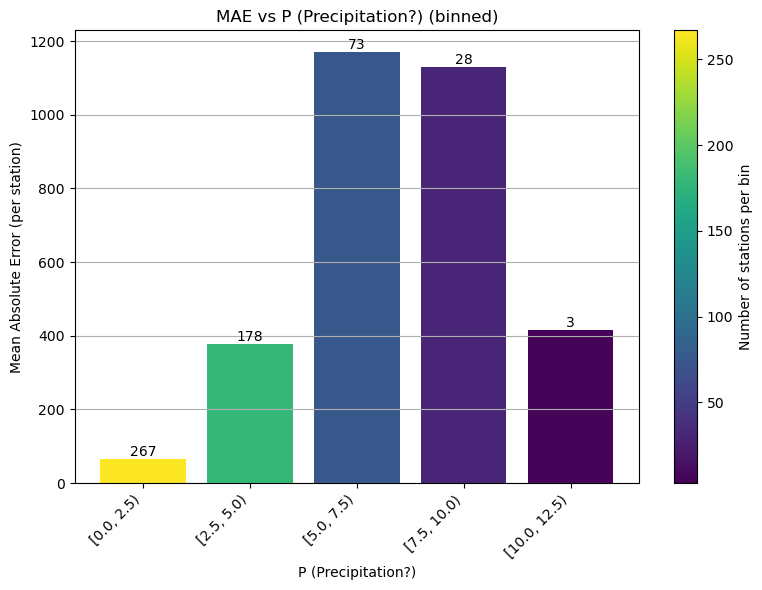

In [102]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

def plot_feature_vs_station_error_colored(df, feature_col, feature_name, bins):
    plt.figure(figsize=(8,6))
    
    # Bin the feature using custom edges
    df['feature_bin'] = pd.cut(df[feature_col], bins=bins, right=False)
    
    # Compute mean MAE per bin
    bin_error = df.groupby('feature_bin', observed=True)['error'].mean()
    
    # Count number of stations per bin
    bin_counts = df.groupby('feature_bin', observed=True)['error'].count()
    
    # Normalize counts for coloring
    colors = plt.cm.viridis(bin_counts / bin_counts.max())
    
    # Plot bars with color
    bars = plt.bar(bin_error.index.astype(str), bin_error.values, color=colors, width=0.8)
    
    # Add counts on top of bars
    for bar, count in zip(bars, bin_counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height, str(count), 
                 ha='center', va='bottom', fontsize=10)
    
    plt.xlabel(feature_name)
    plt.ylabel('Mean Absolute Error (per station)')
    plt.title(f'MAE vs {feature_name} (binned)')
    plt.xticks(rotation=45, ha='right')
    
    # Create a colorbar manually
    sm = mpl.cm.ScalarMappable(cmap='viridis', 
                               norm=mpl.colors.Normalize(vmin=bin_counts.min(), vmax=bin_counts.max()))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca())
    cbar.set_label('Number of stations per bin')
    
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


# --- Custom bin edges ---
lat_bins = np.arange(-40, 50, 10)
area_bins = np.arange(1e4, 5.5e5, 5e4)
P_bins = np.arange(0, 15, 2.5)

# Plot
plot_feature_vs_station_error_colored(station_error, 'lat', 'Latitude', lat_bins)
plot_feature_vs_station_error_colored(station_error, 'area_delin', 'Area Delineation', area_bins)
plot_feature_vs_station_error_colored(station_error, 'P', 'P (Precipitation?)', P_bins)

## Recreate Timeseries

In [76]:
# Re-create timeseries
station_no = total_df['grdc_no'].unique()
freq_stations = total_df['grdc_no'].value_counts()

N = 50
rand_stations = np.random.choice(station_no, size=N, replace=False)
print(rand_stations[0])

1259101


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/tmp/ipykernel_3546043/2221606042.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - (np.sum((targets - predictions) ** 2) / np.sum((targets - np.mean(targets)) ** 2))


Station 1259101 | NSE: -inf | MAPE: 969207195.82%


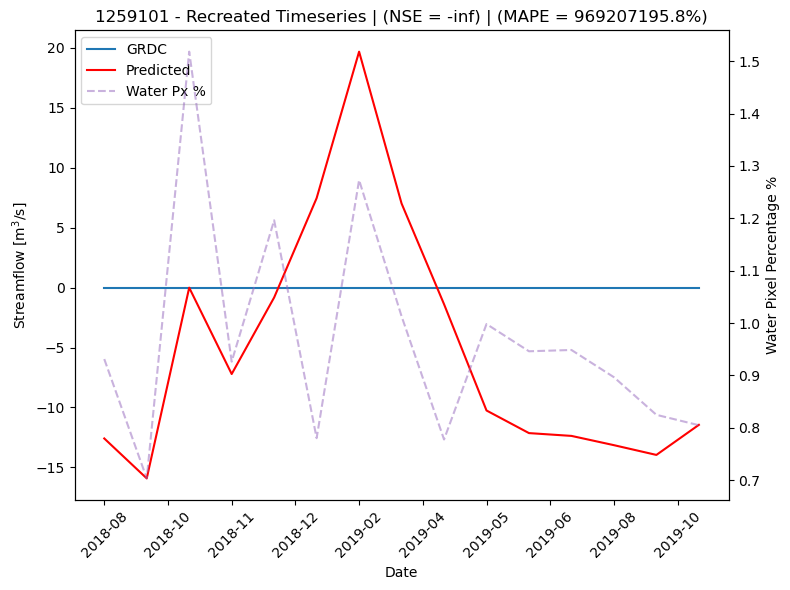

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 4123095 | NSE: 0.428 | MAPE: 49.93%


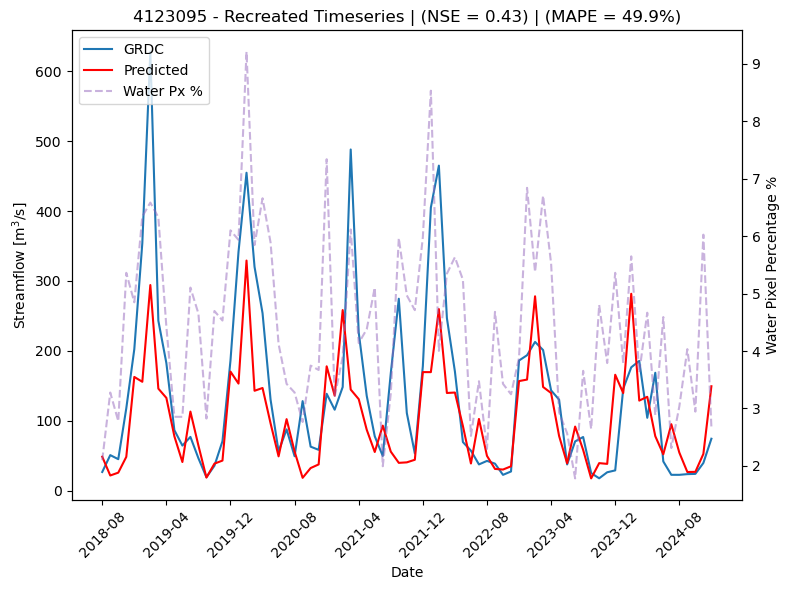

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 4148650 | NSE: 0.082 | MAPE: 42.10%


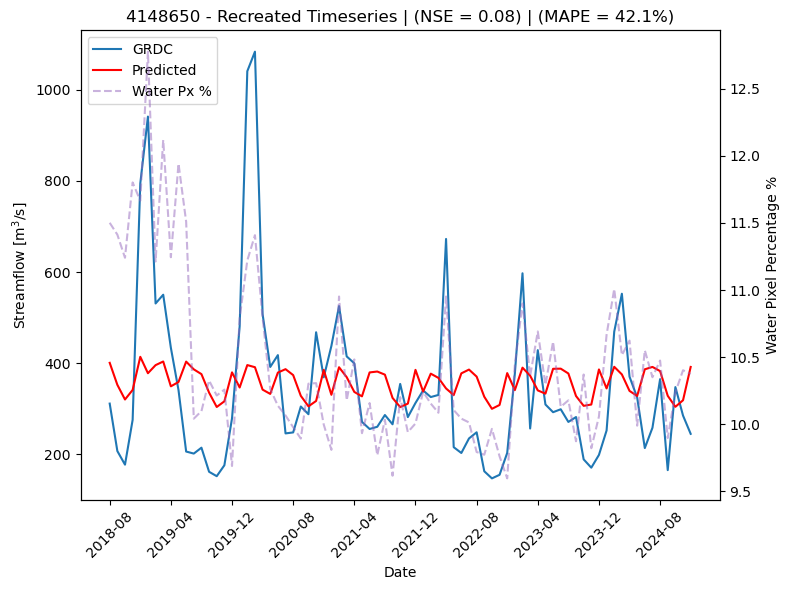

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 5204451 | NSE: 0.212 | MAPE: 457239257.96%


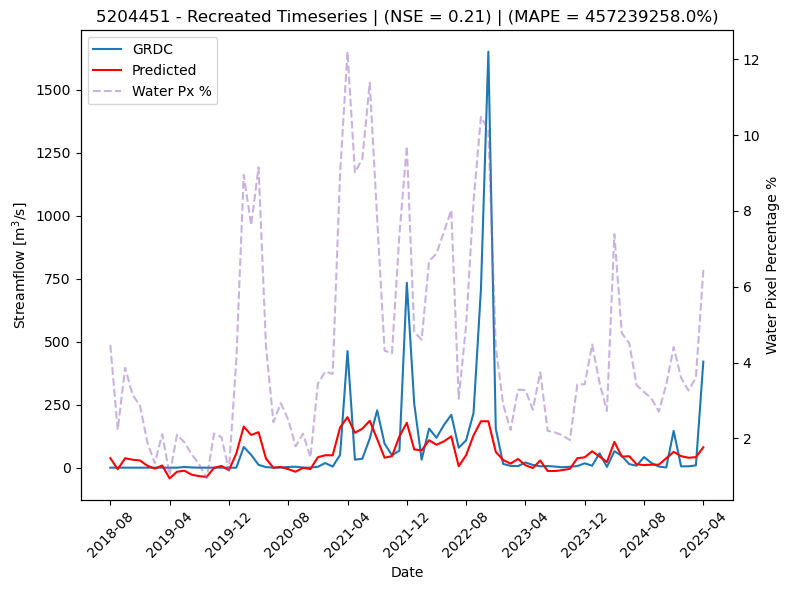

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3650460 | NSE: -72.833 | MAPE: 27995.60%


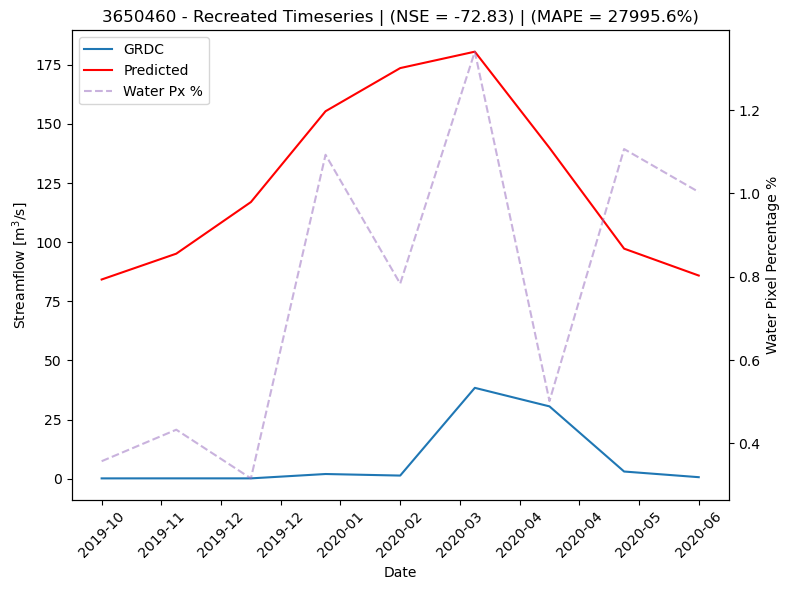

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 4148232 | NSE: -0.042 | MAPE: 158.55%


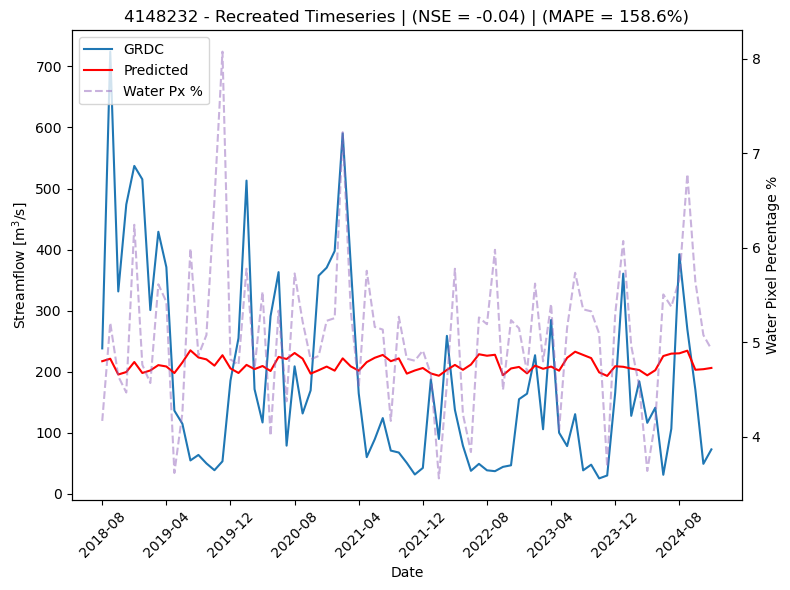

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3649321 | NSE: -1.139 | MAPE: 42.23%


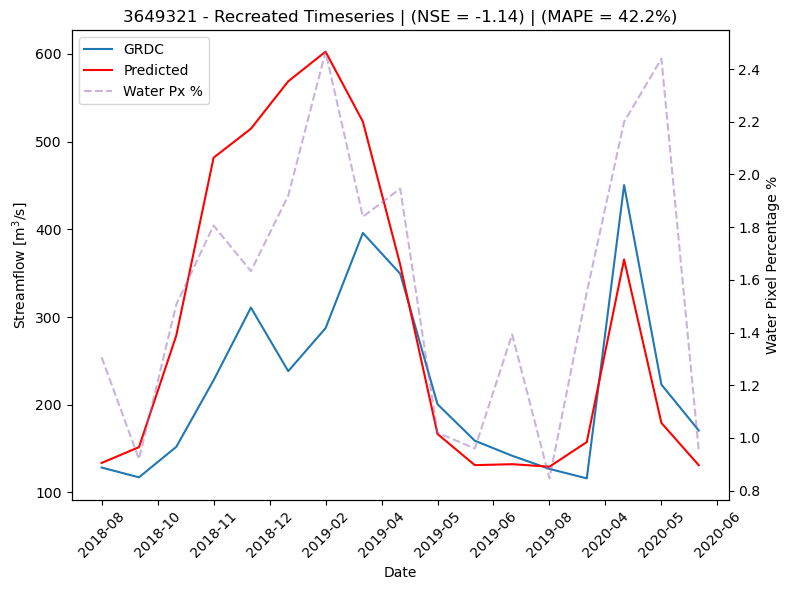

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 1616700 | NSE: 0.112 | MAPE: 201.59%


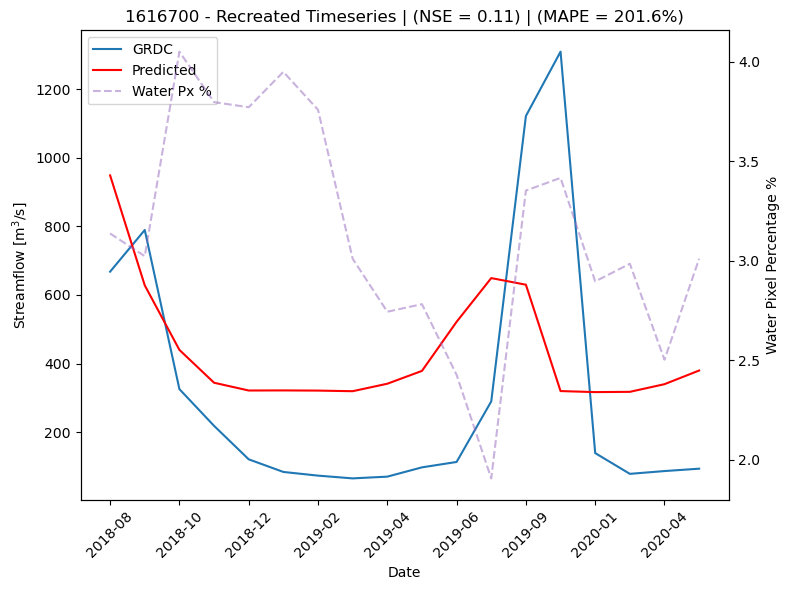

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 5204107 | NSE: -0.322 | MAPE: 846.26%


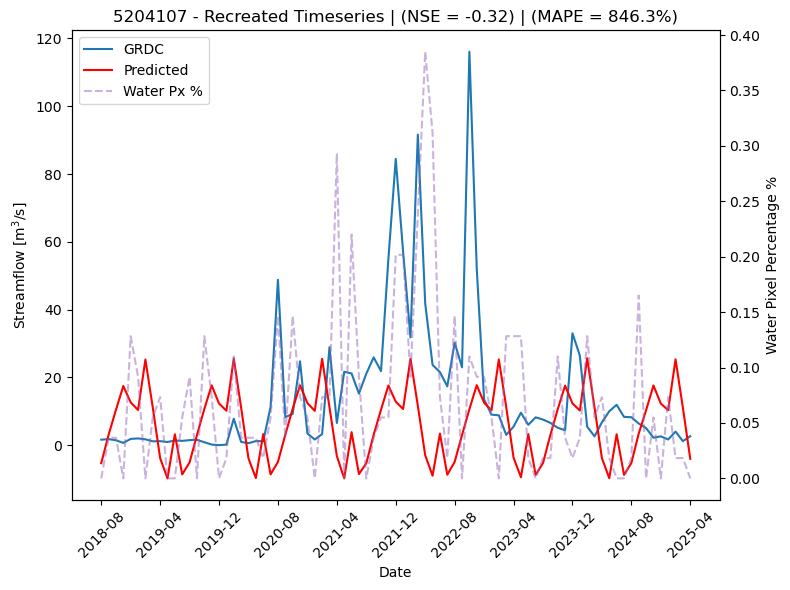

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 1160460 | NSE: -32.318 | MAPE: 8039.41%


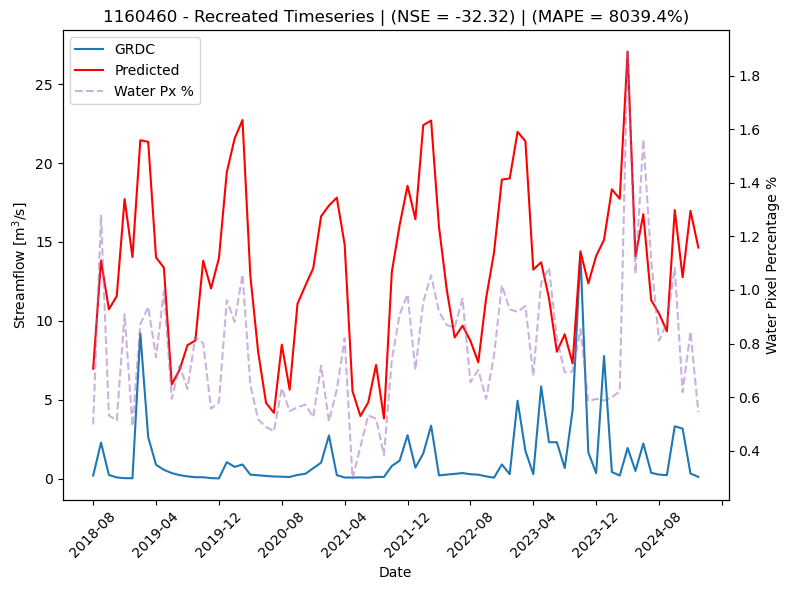

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Station 1196440 | NSE: 0.170 | MAPE: 136.83%


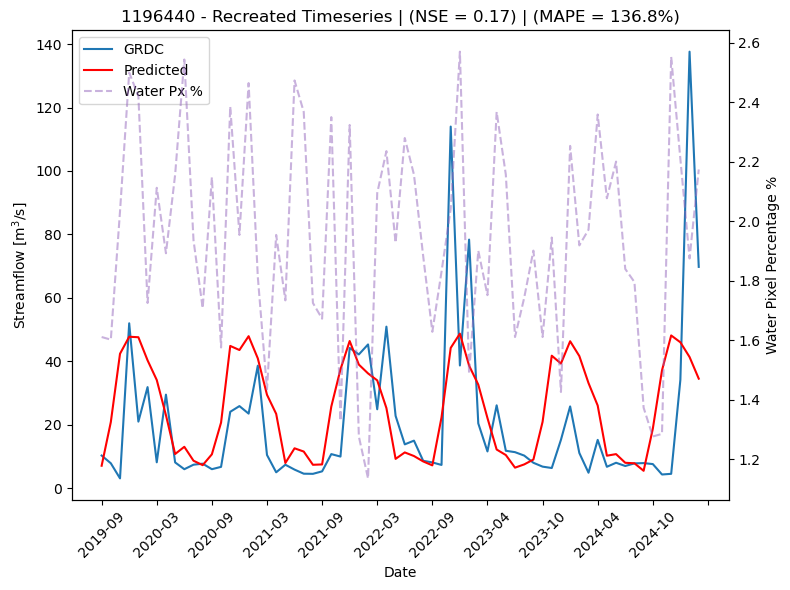

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 4149851 | NSE: -1.679 | MAPE: 516814823.66%


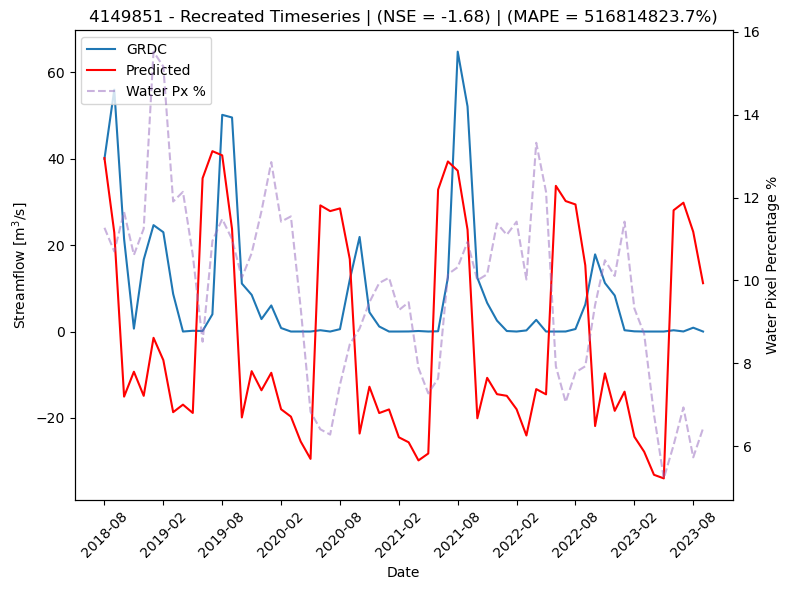

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3107015 | NSE: 0.832 | MAPE: 42.95%


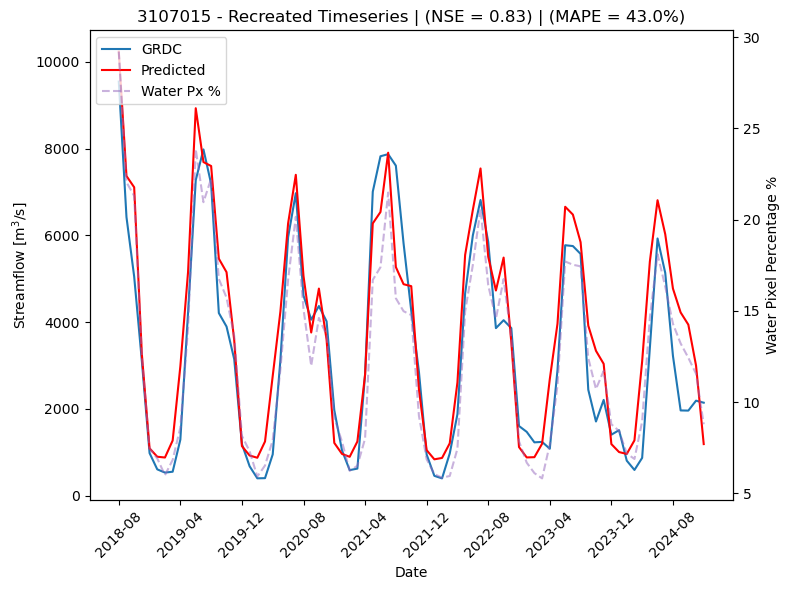

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 4126810 | NSE: -0.245 | MAPE: 22151828.86%


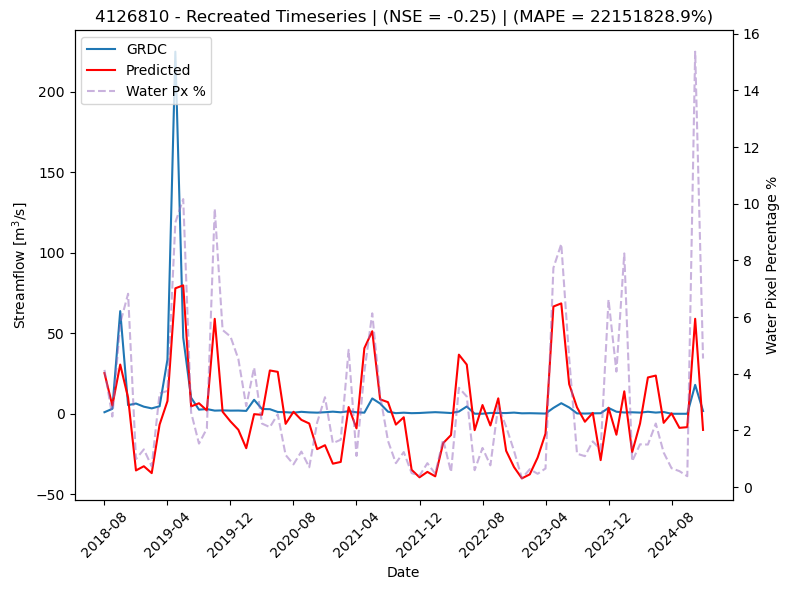

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 4152466 | NSE: -55.297 | MAPE: 11512748.59%


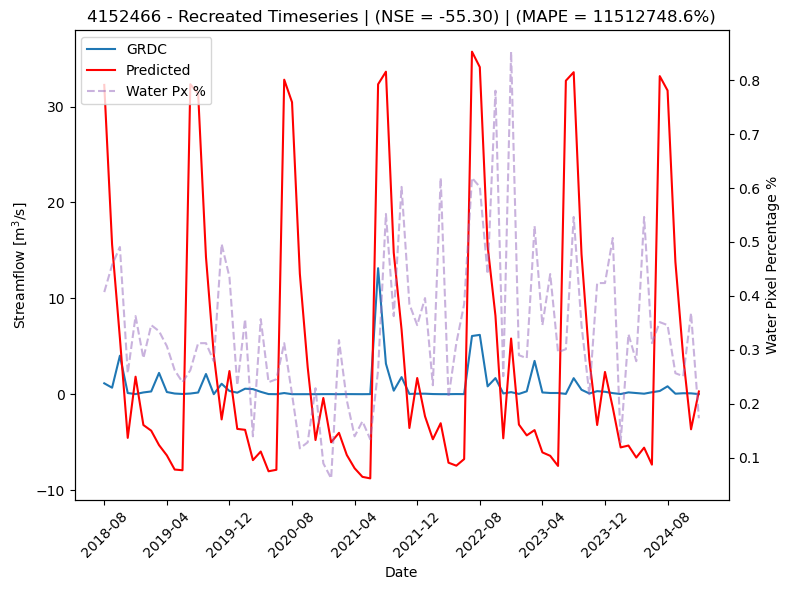

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 1320100 | NSE: -0.707 | MAPE: 225.20%


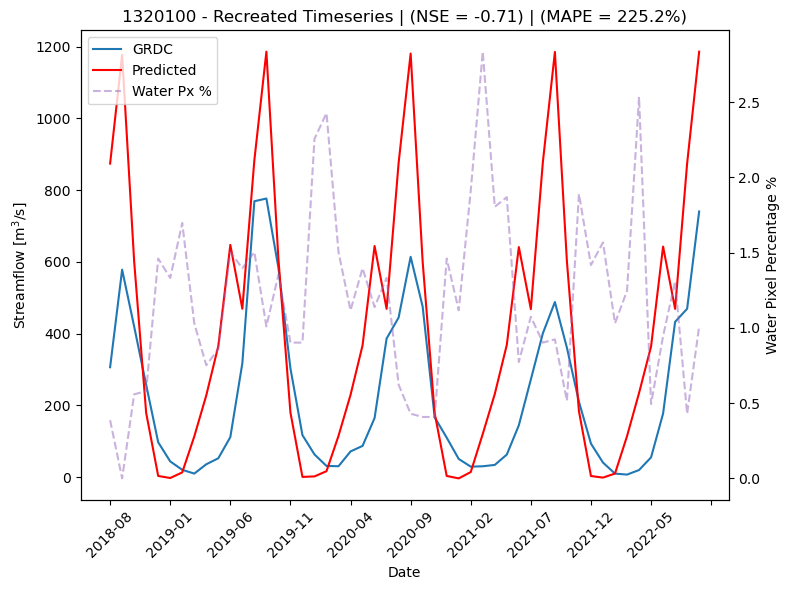

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 1160235 | NSE: 0.199 | MAPE: 309601887.05%


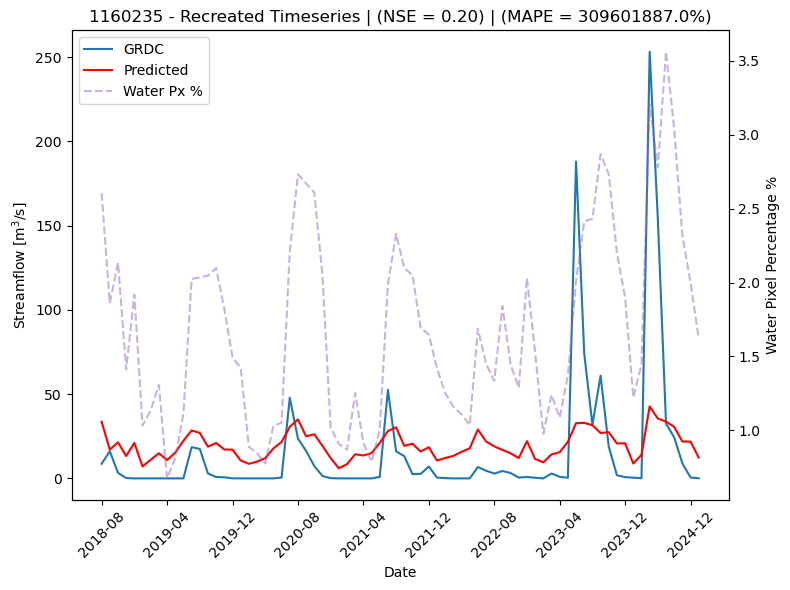

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3102010 | NSE: 0.569 | MAPE: 31.01%


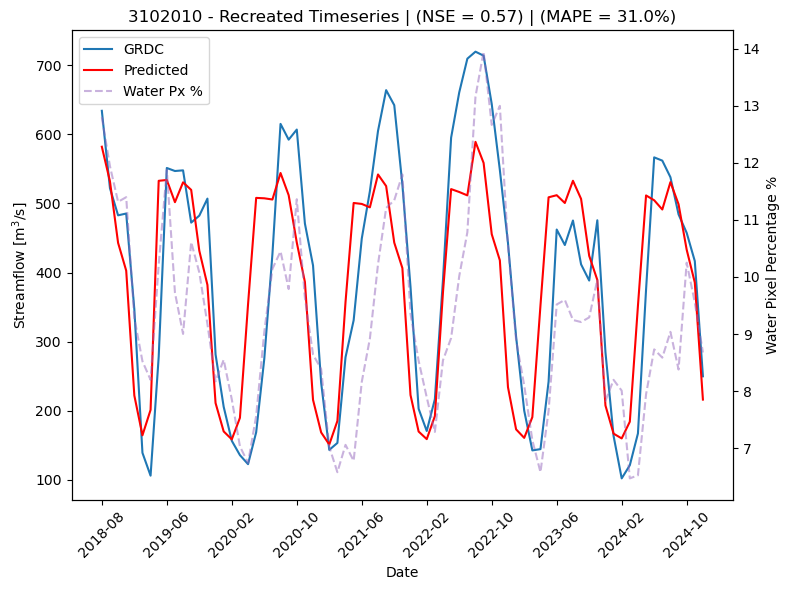

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3634380 | NSE: 0.652 | MAPE: 41.94%


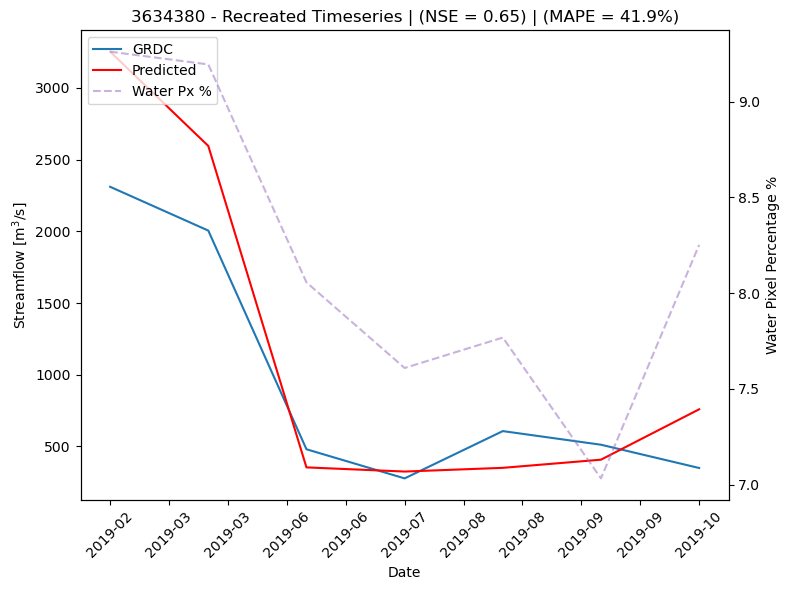

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 4149441 | NSE: 0.301 | MAPE: 74.18%


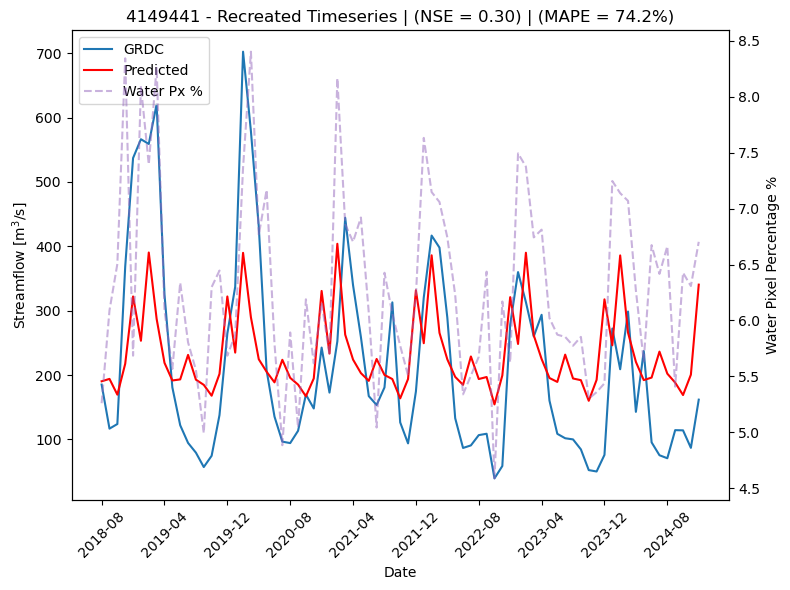

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 5404270 | NSE: -0.135 | MAPE: 137.84%


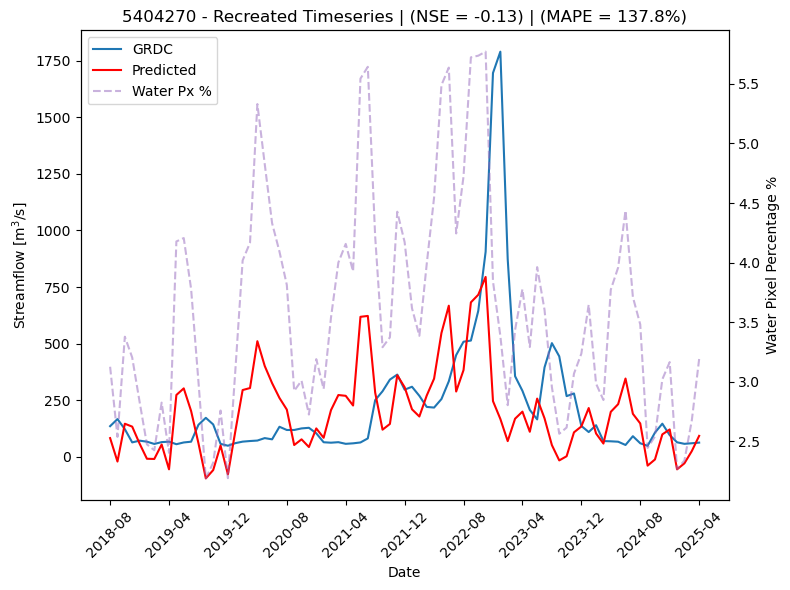

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3617811 | NSE: 0.634 | MAPE: 144.13%


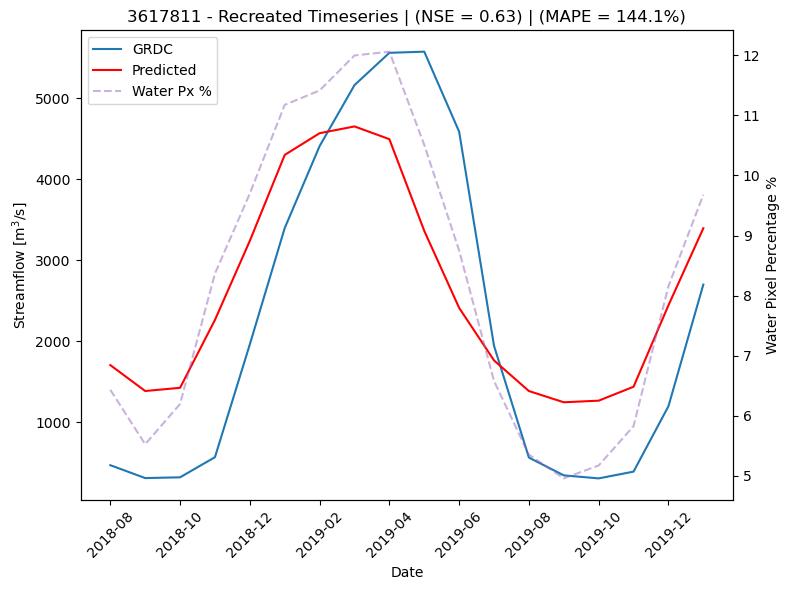

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3649905 | NSE: 0.146 | MAPE: 31.29%


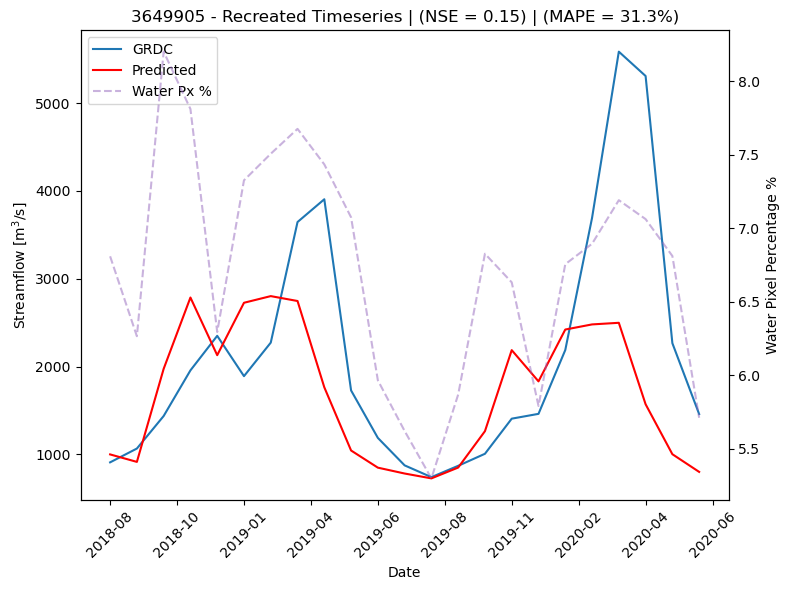

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3275010 | NSE: -353.676 | MAPE: 4470.48%


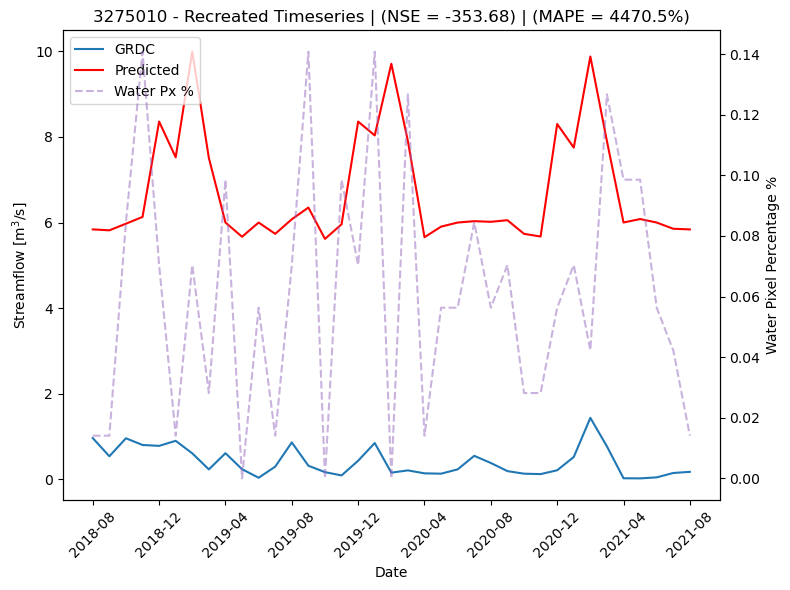

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 4149691 | NSE: -0.033 | MAPE: 96.73%


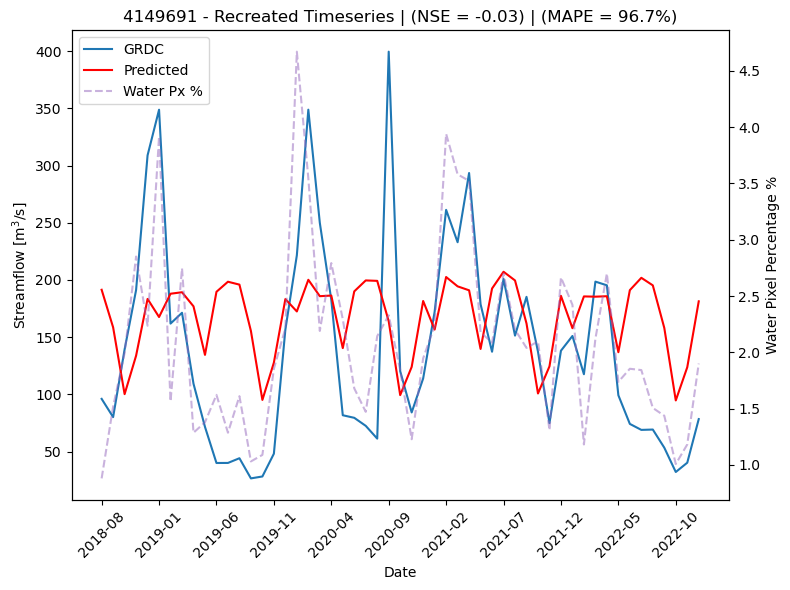

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 4126701 | NSE: 0.067 | MAPE: 137.54%


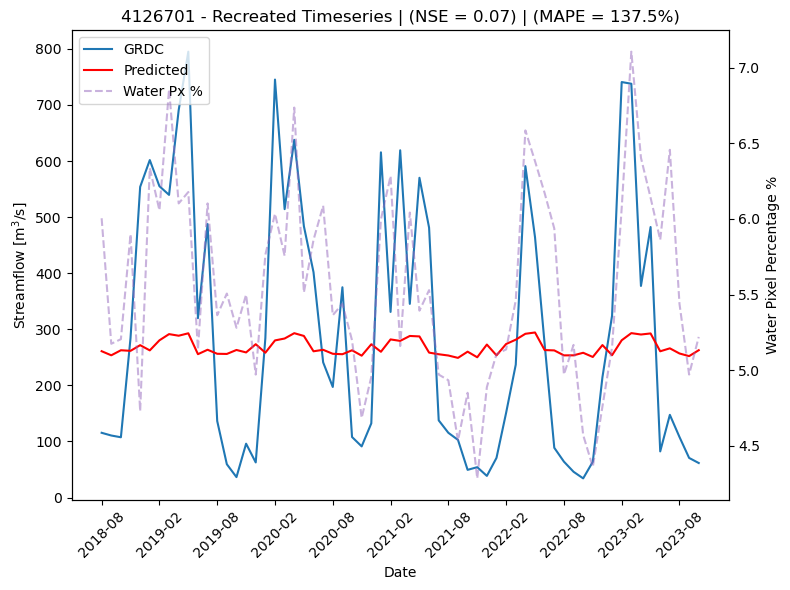

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 4148570 | NSE: 0.234 | MAPE: 61.13%


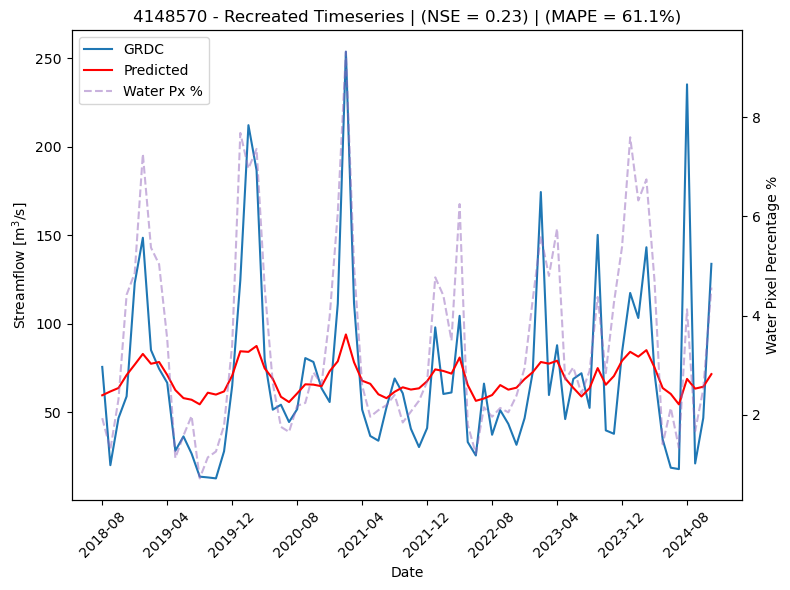

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3632450 | NSE: 0.620 | MAPE: 52.75%


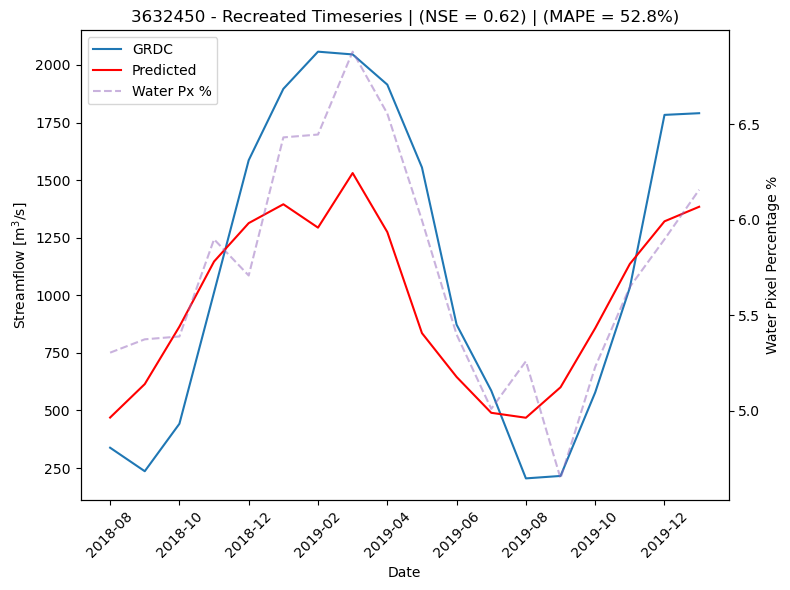

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3635402 | NSE: 0.594 | MAPE: 71.76%


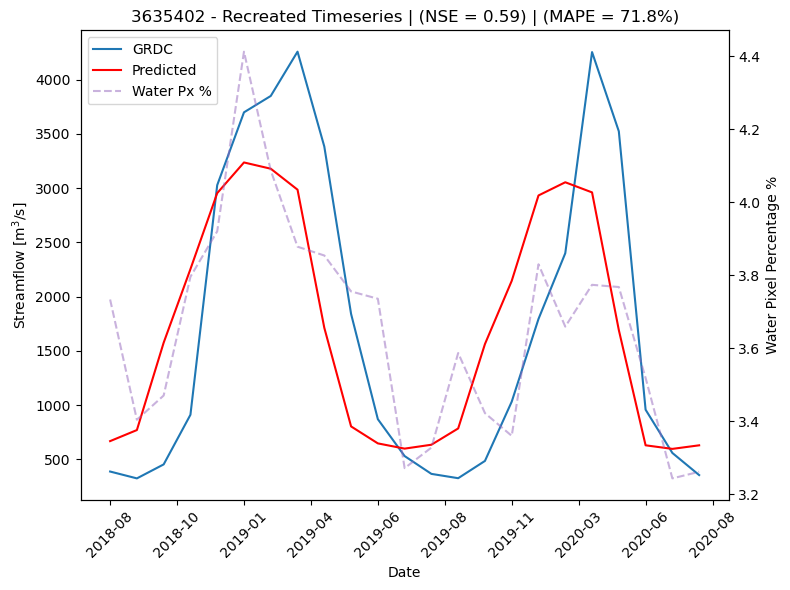

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 1159100 | NSE: 0.072 | MAPE: 312.60%


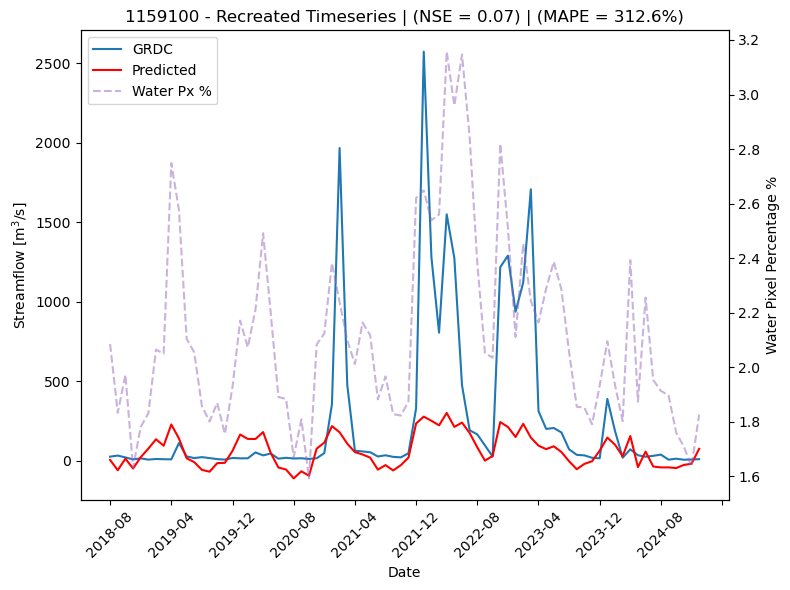

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 1234130 | NSE: 0.480 | MAPE: 383304637.92%


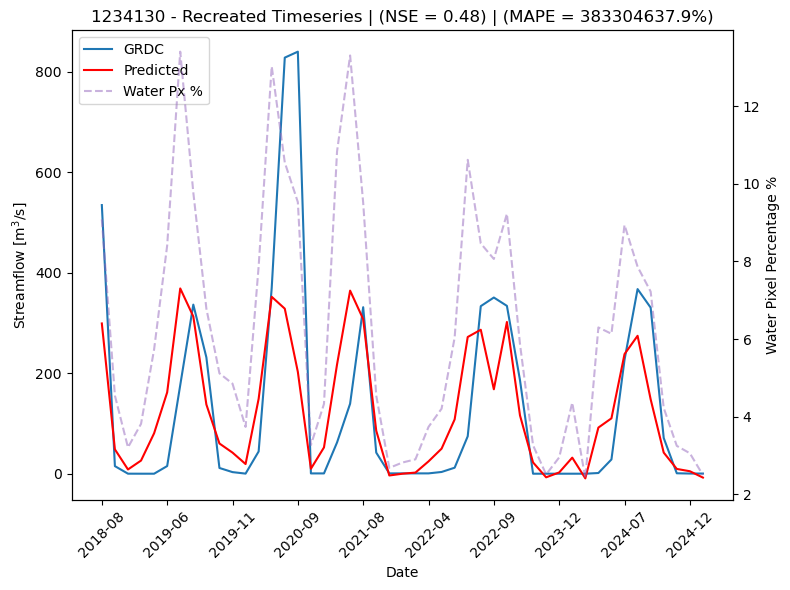

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 5202044 | NSE: 0.060 | MAPE: 1255.72%


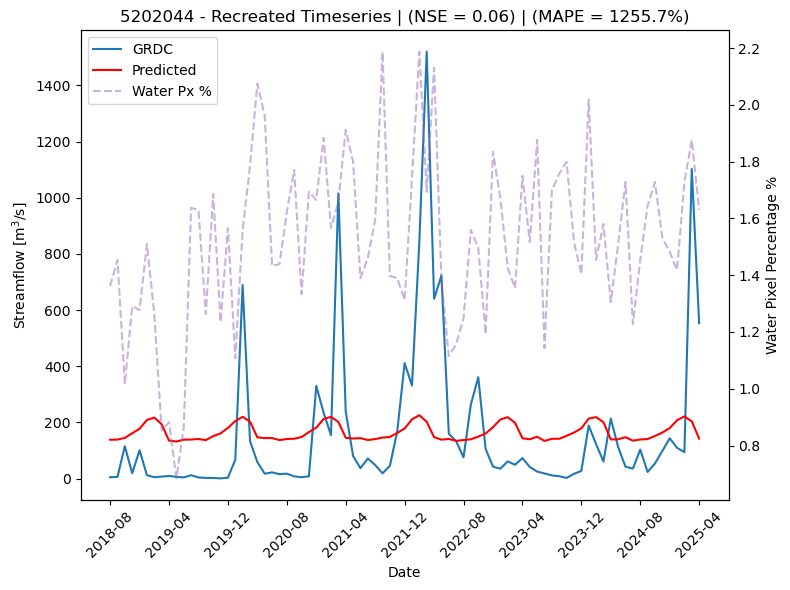

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3179890 | NSE: -4257.064 | MAPE: 1428.80%


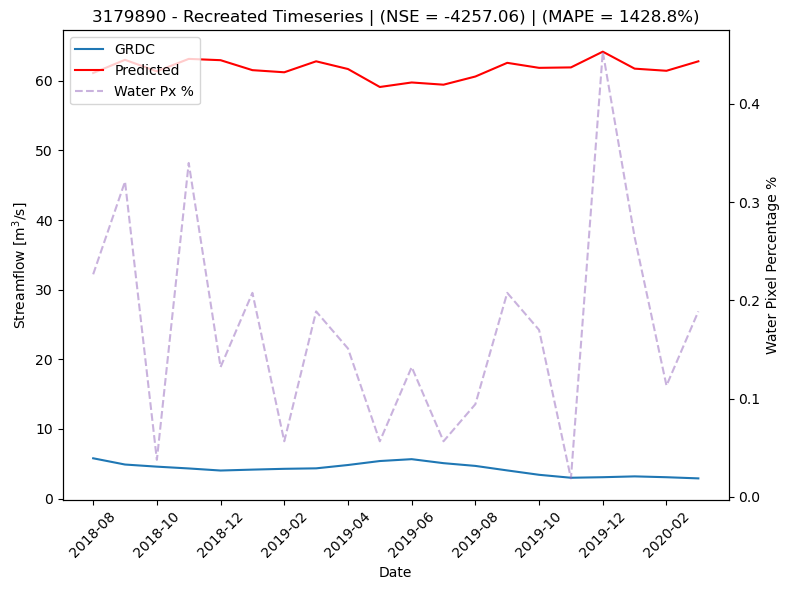

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 1196100 | NSE: 0.074 | MAPE: 83.29%


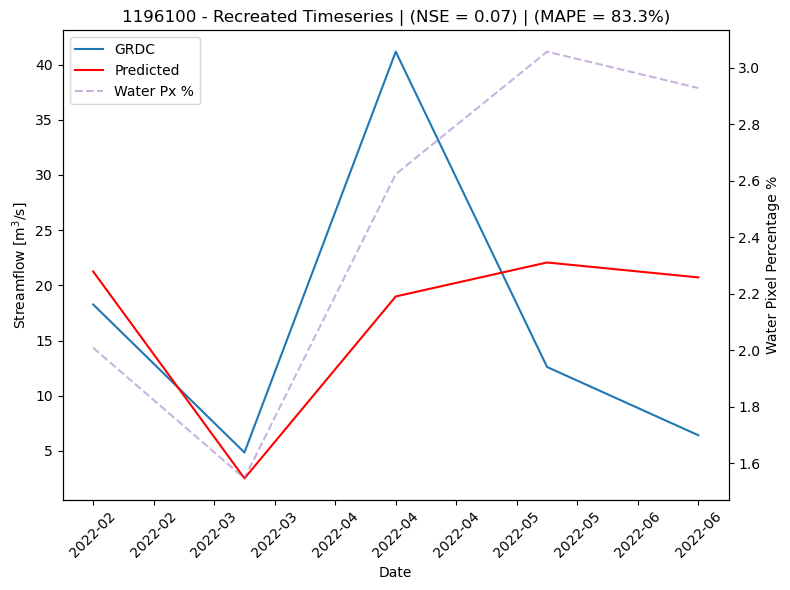

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3613060 | NSE: 0.005 | MAPE: 43.02%


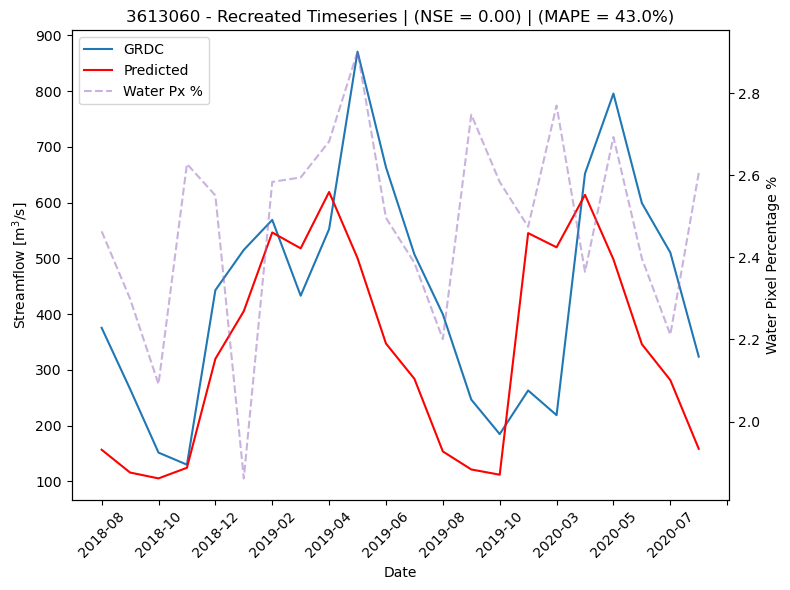

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3649459 | NSE: -3.969 | MAPE: 57.58%


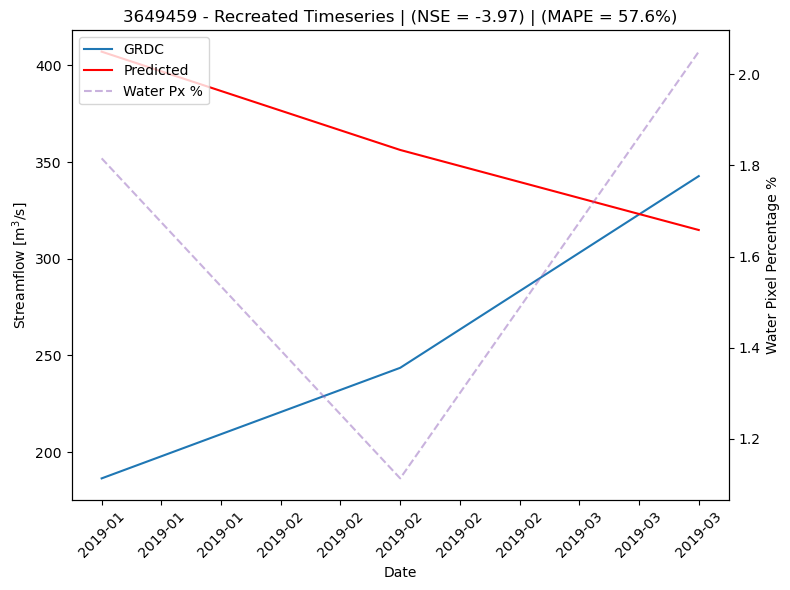

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 1159550 | NSE: 0.173 | MAPE: 193.05%


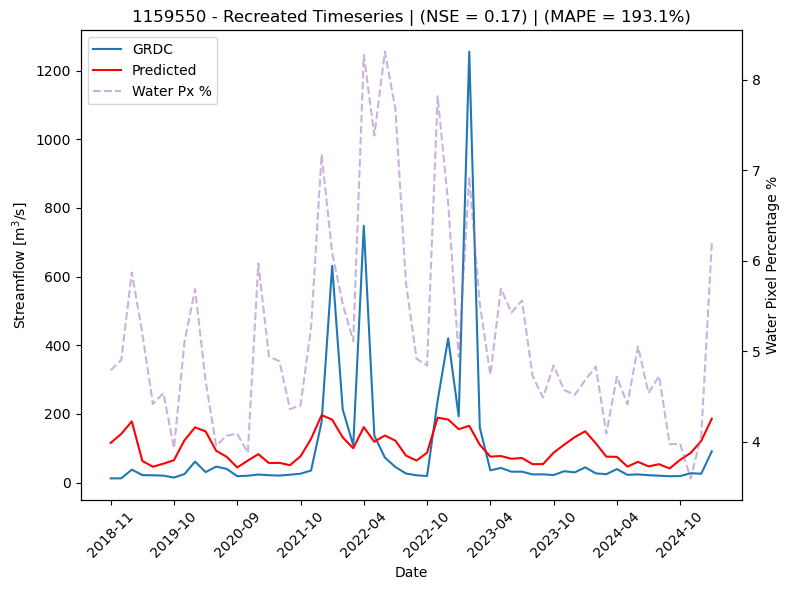

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3633122 | NSE: 0.284 | MAPE: 99.51%


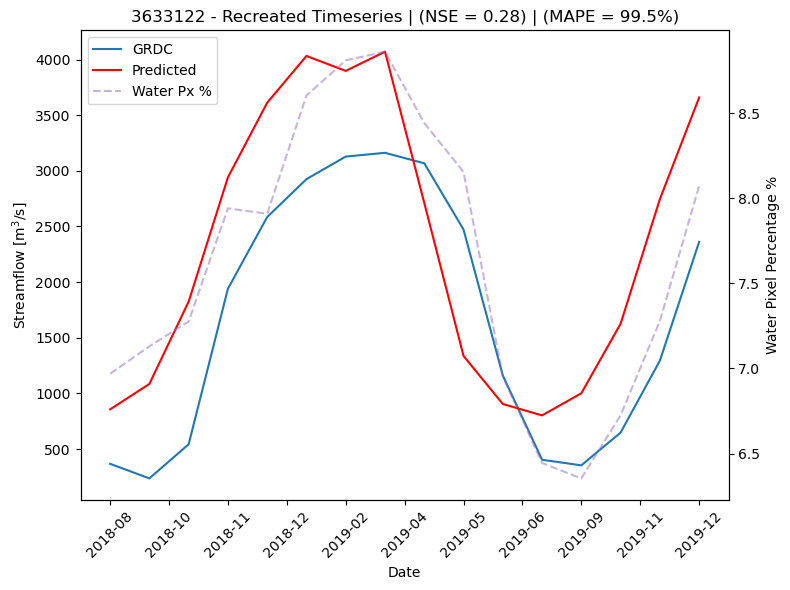

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3179800 | NSE: -347521.168 | MAPE: 6238.76%


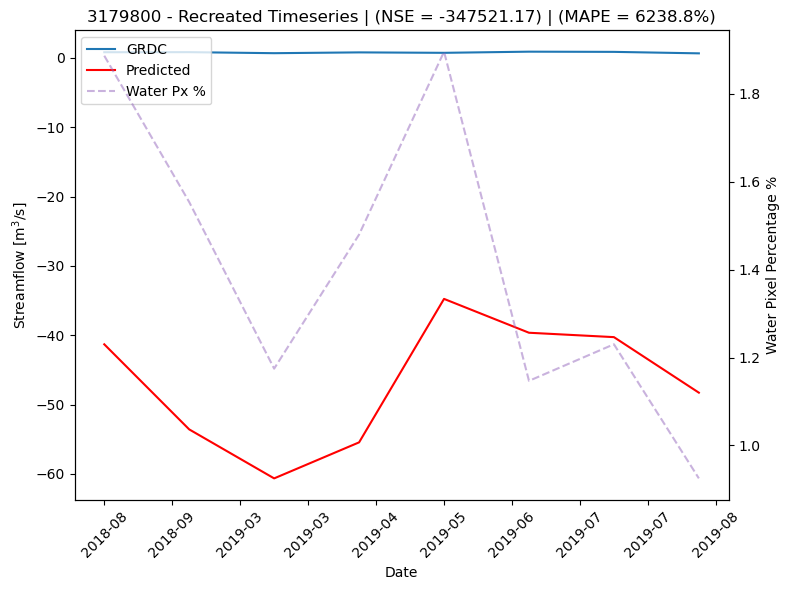

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 5204452 | NSE: 0.244 | MAPE: 303097941.90%


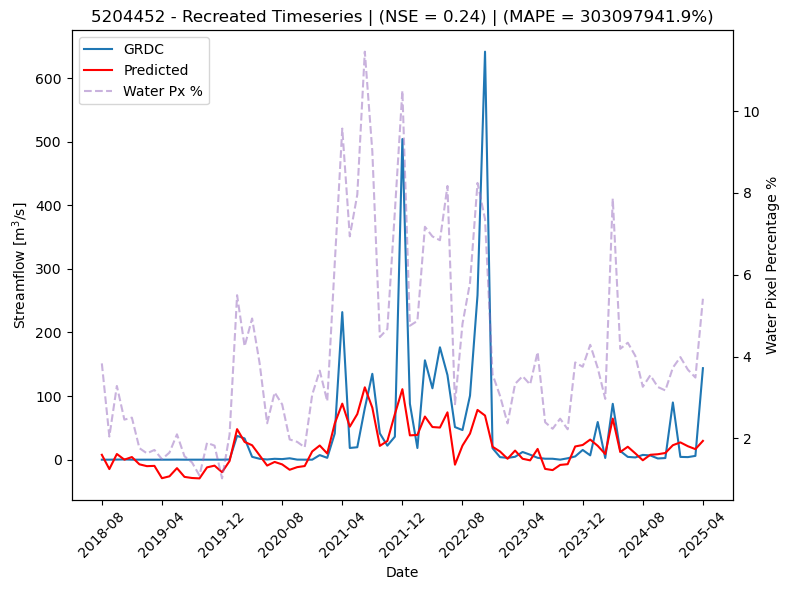

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 5101301 | NSE: 0.256 | MAPE: 1290356503.84%


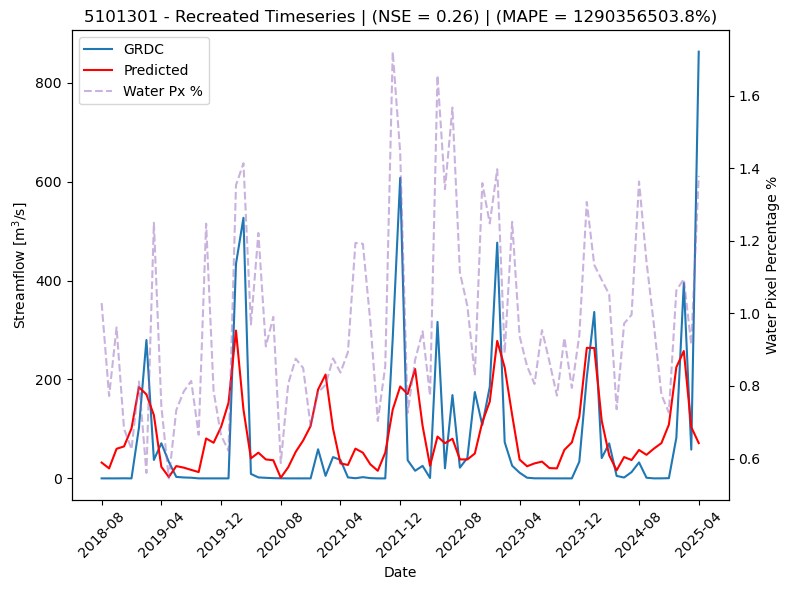

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 1259100 | NSE: 0.187 | MAPE: 608471679.20%


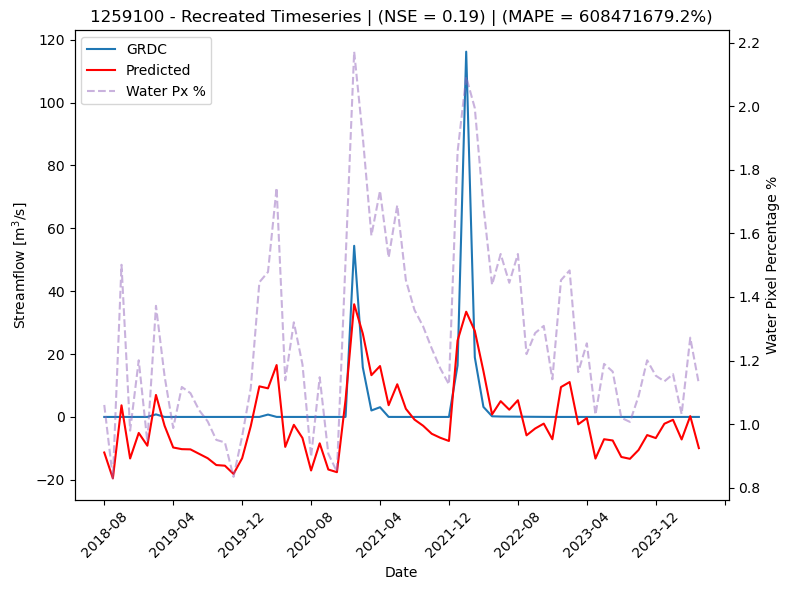

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 1259450 | NSE: -2118551.427 | MAPE: 1773091195.96%


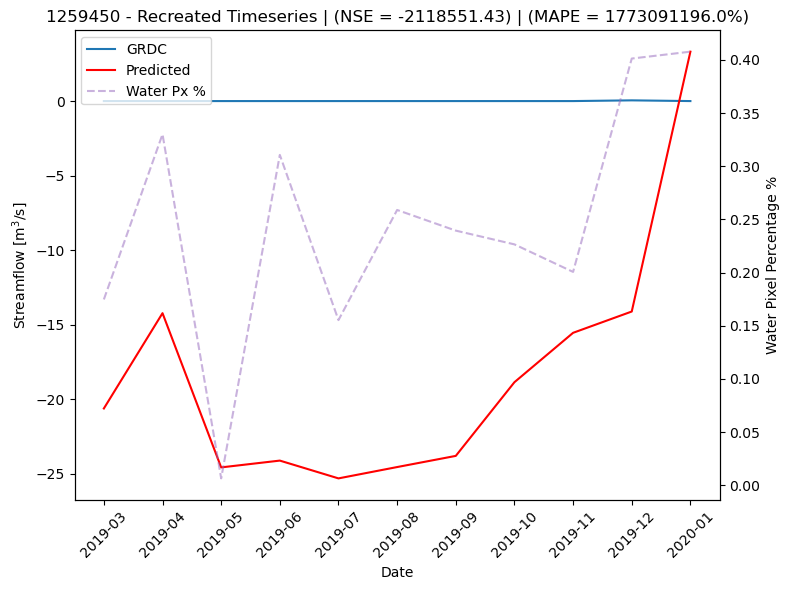

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 3635301 | NSE: -0.852 | MAPE: 387.67%


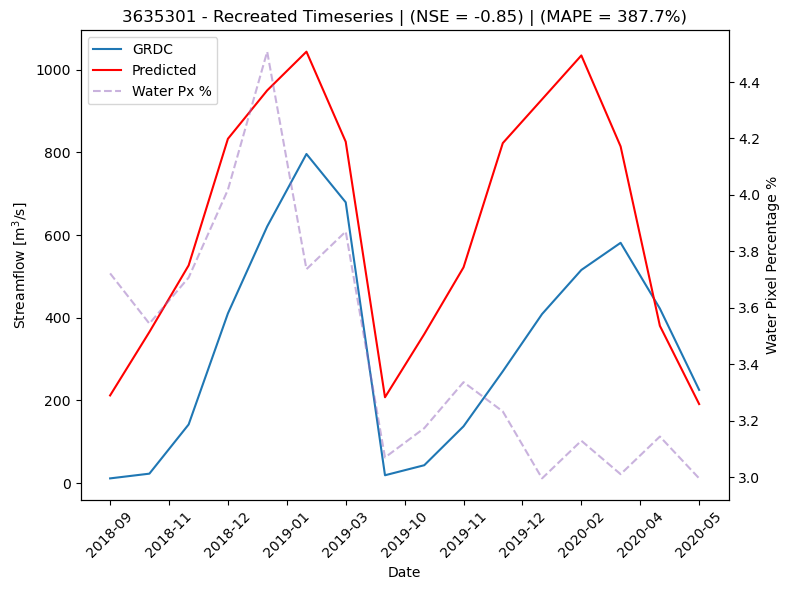

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 1159305 | NSE: -4779.368 | MAPE: 975514740.27%


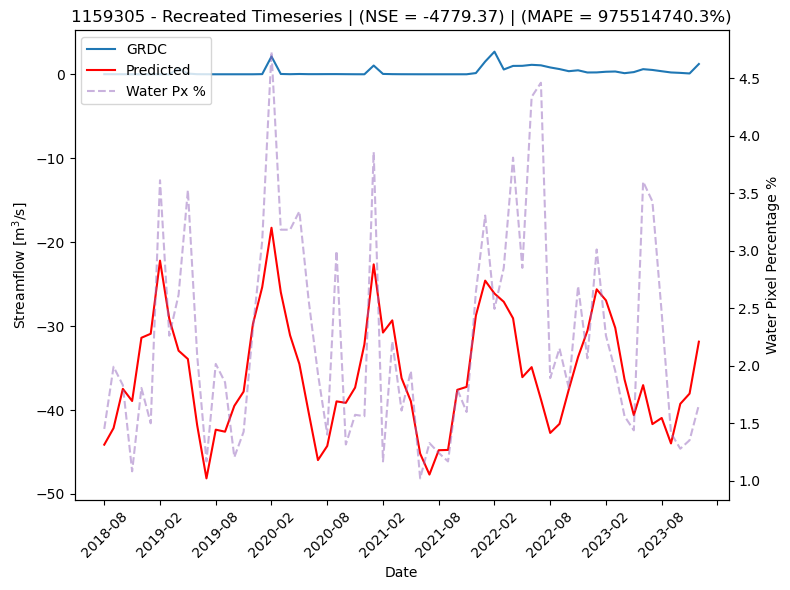

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 1257101 | NSE: -0.381 | MAPE: 41.69%


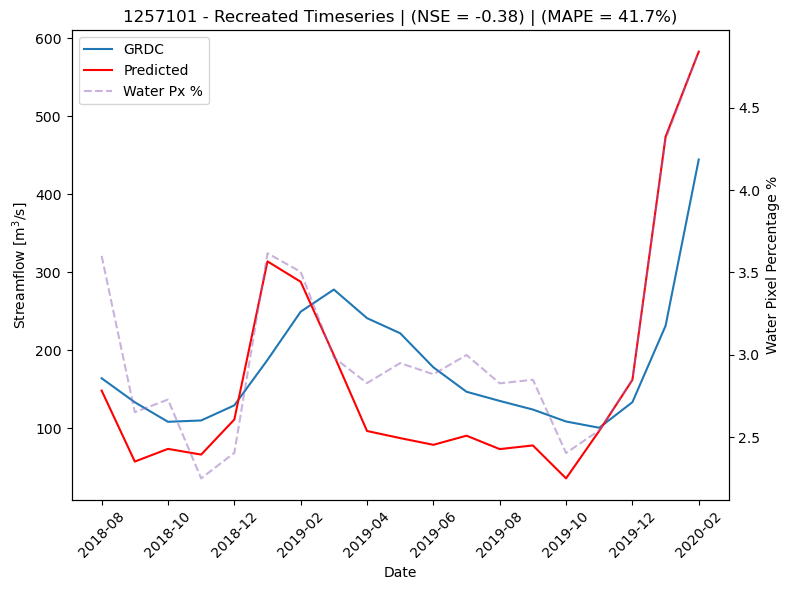

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 4126851 | NSE: -286.106 | MAPE: 25056608.70%


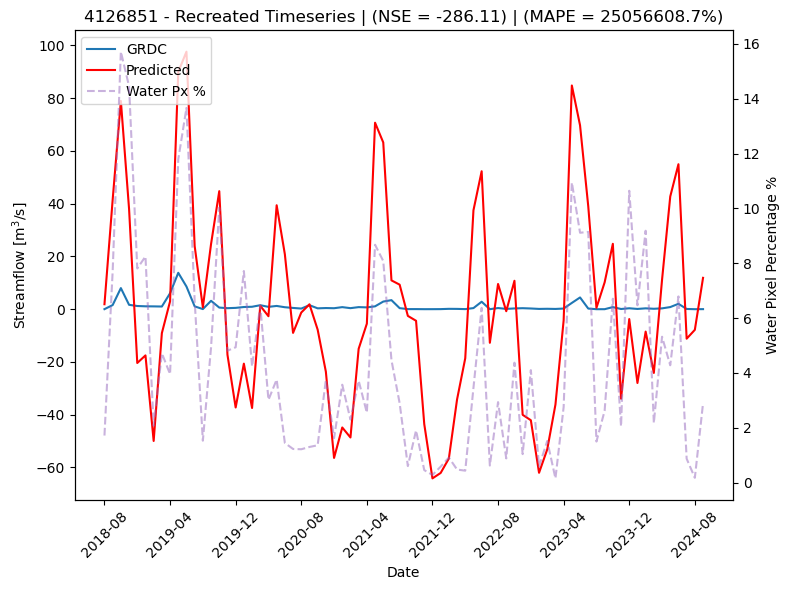

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 4150502 | NSE: -0.152 | MAPE: 49768302.39%


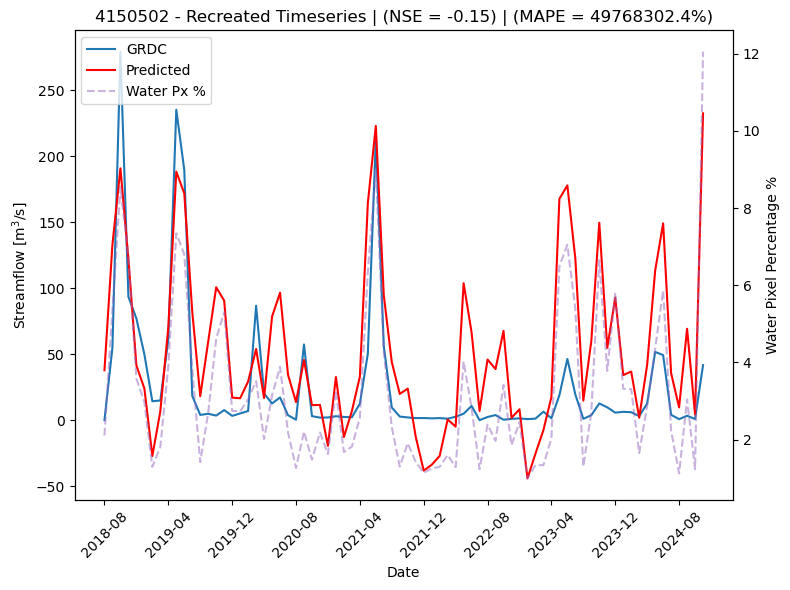

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 4149781 | NSE: 0.085 | MAPE: 37.27%


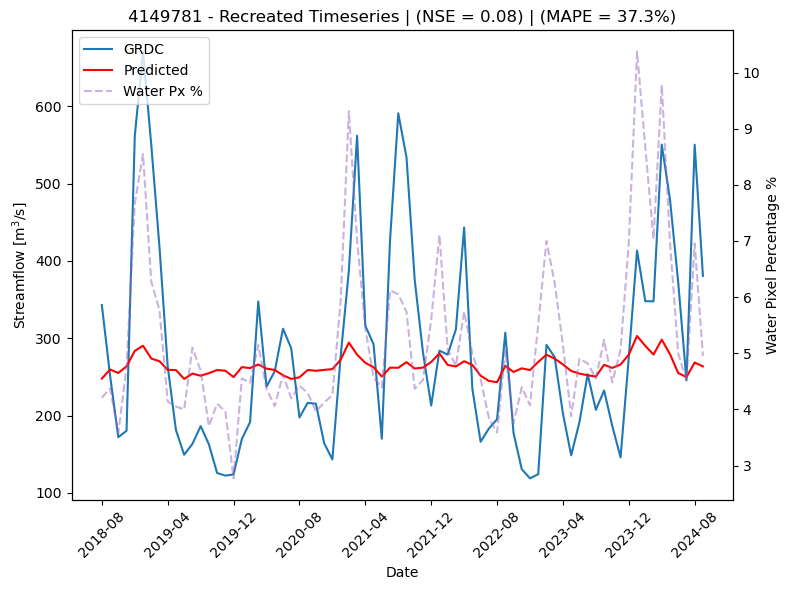

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Station 1159103 | NSE: 0.200 | MAPE: 324.98%


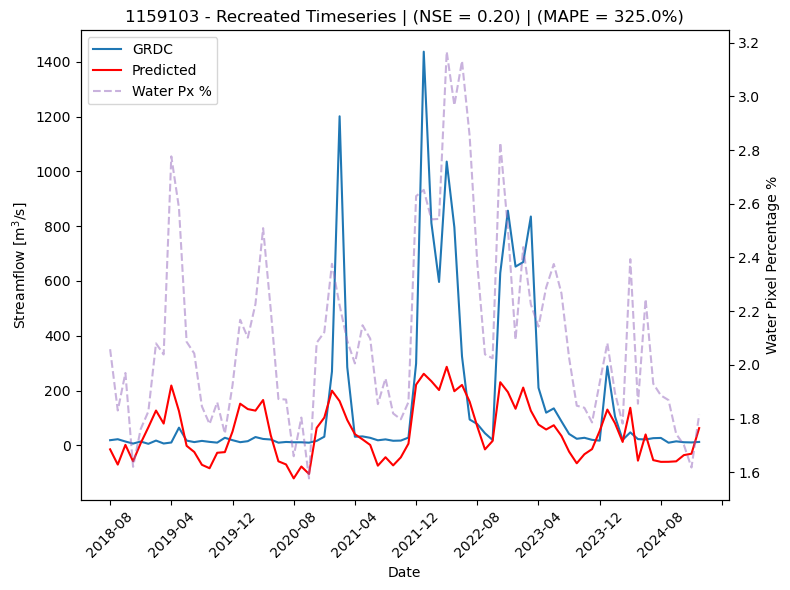

In [97]:
import numpy as np
import matplotlib.ticker as ticker

# Optional: store MAPE per station
mape_by_station = {}

for i in range(0, len(rand_stations)):

    test_station_num = int(rand_stations[i])
    test_station_info = total_df[total_df['grdc_no'] == test_station_num]

    # ----------------------------
    # True Q values (UNSCALED)
    # ----------------------------
    y_true = test_station_info['Q'].to_numpy()

    # Scaled targets (for NSE if you want it)
    targets_scaled = scaler_y.transform(
        y_true.reshape(-1, 1)
    ).flatten()

    # ----------------------------
    # Input features
    # ----------------------------
    test_X = test_station_info.drop([
        'Date', 'grdc_no', 'river', 'station', 'country', 'long', 'area',
        'altitude', 'Q', 'SWE', 'r2'
    ], axis=1)

    test_X_scaled = scaler_X.transform(test_X)

    # ----------------------------
    # Predict
    # ----------------------------
    test_pred_scaled = model.predict(test_X_scaled).flatten()

    test_pred = scaler_y.inverse_transform(
        test_pred_scaled.reshape(-1, 1)
    ).flatten()

    # ----------------------------
    # Metrics
    # ----------------------------

    # NSE (still using scaled values, as you had)
    nse_value = nse(test_pred_scaled, targets_scaled)

    # MAPE (UNSCALED, with zero protection)
    eps = 1e-6
    mape_value = np.mean(
        np.abs((y_true - test_pred) / (y_true + eps))
    ) * 100

    # Save MAPE
    mape_by_station[test_station_num] = mape_value

    print(f"Station {test_station_num} | NSE: {nse_value:.3f} | MAPE: {mape_value:.2f}%")

    # ----------------------------
    # Plot
    # ----------------------------
    fig, ax1 = plt.subplots(figsize=(8, 6))

# Primary axis: Streamflow
    ax1.plot(
        test_station_info['Date'],
        y_true,
        label='GRDC',
        linewidth=1.5
    )
    ax1.plot(
        test_station_info['Date'],
        test_pred,
        label='Predicted',
        color='r',
        linewidth=1.5
    )
    
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Streamflow [m$^3$/s]')
    ax1.xaxis.set_major_locator(ticker.MaxNLocator(nbins=12))
    plt.setp(ax1.get_xticklabels(), rotation=45)
    
    # Secondary axis: SWE
    ax2 = ax1.twinx()
    ax2.plot(
        test_station_info['Date'],
        test_station_info['SWE'],
        label='Water Px %',
        color='tab:purple',
        alpha=0.5,
        linestyle='--'
    )
    ax2.set_ylabel('Water Pixel Percentage %')
    
    # Combine legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
    
    # Title with MAPE
    plt.title(
        f'{test_station_num} - Recreated Timeseries | '
        f'(NSE = {nse_value:.2f}) | '
        f'(MAPE = {mape_value:.1f}%)'
    )
    
    plt.tight_layout()
    
    # plt.savefig(f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/TIMESERIES/MONTHLY_PREDICTED/{test_station_num}.png')
    
    plt.show()

## Save Model Architecture and Analysis

In [86]:
# # !pip install shap
import shap

# explainer = shap.Explainer(model.predict, X_test)
# shap_values = explainer.shap_values(X_test)

import numpy as np

# choose N points to explain
N = 500  
idx = np.random.choice(len(X_test), size=N, replace=False)

X_test_subset = X_test[idx]

explainer = shap.Explainer(model.predict, X_test_subset)
shap_values = explainer(X_test_subset)

192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


PermutationExplainer explainer:   0%|          | 1/500 [00:00<?, ?it/s]

217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


PermutationExplainer explainer:   1%|          | 3/500 [00:15<18:34,  2.24s/it]

207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


...

PermutationExplainer explainer: 100%|█████████▉| 499/500 [19:17<00:02,  2.36s/it]

197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 681us/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 688us/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 760us/step


PermutationExplainer explainer: 100%|██████████| 500/500 [19:19<00:00,  2.33s/it]

196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step


PermutationExplainer explainer: 501it [19:22,  2.32s/it]                         


/tmp/ipykernel_3546043/3698350739.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_subset,feature_names=shap_features)


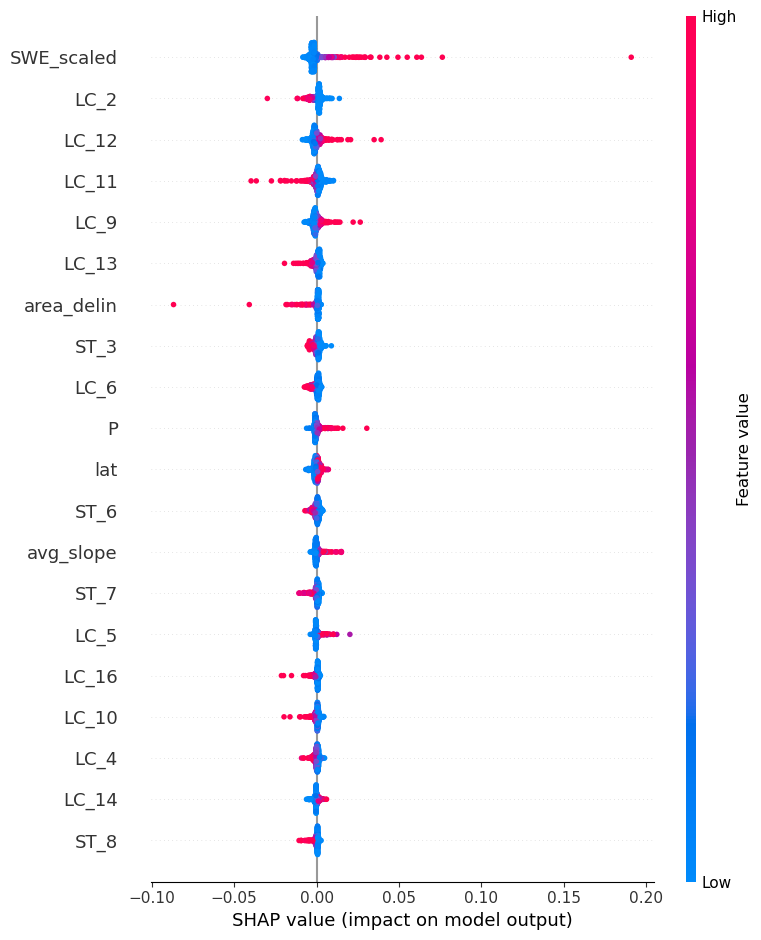

In [87]:
shap_features = ['lat', 'area_delin', 'SWE_scaled', 'P', 'avg_slope', 'max_slope', 'LC_1', 'LC_2', 'LC_3', 'LC_4', 
                 'LC_5', 'LC_6', 'LC_7', 'LC_8', 'LC_9', 'LC_10', 'LC_11', 'LC_12', 'LC_13', 'LC_14', 'LC_15', 
                 'LC_16', 'LC_17', 'LC_18', 'LC_19', 'LC_20', 'ST_1', 'ST_2', 'ST_3', 'ST_4', 'ST_5', 'ST_6', 
                 'ST_7', 'ST_8', 'ST_9', 'ST_10', 'ST_11', 'ST_12', 'ST_13', 'ST_14', 'ST_15', 'ST_16']
shap.summary_plot(shap_values, X_test_subset,feature_names=shap_features)

/tmp/ipykernel_3546043/833960656.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_subset, feature_names=shap_features,plot_type="bar")


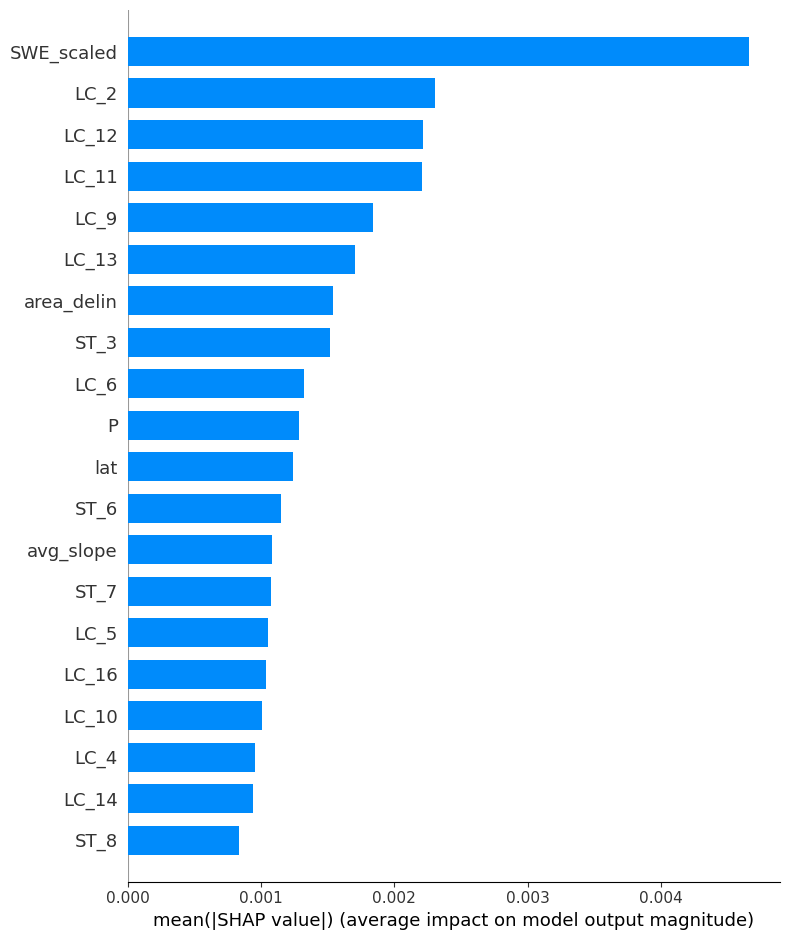

In [88]:
shap.summary_plot(shap_values, X_test_subset, feature_names=shap_features,plot_type="bar")

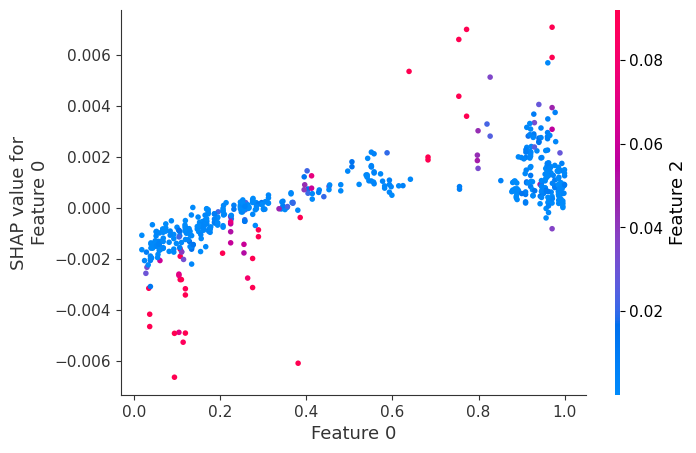

In [89]:
# shap.dependence_plot("Feature 0", shap_values, X_test_subset)
# Fix shape
shap_vals = shap_values.values
if shap_vals.ndim == 3:
    shap_vals = shap_vals[..., 0]

shap.dependence_plot("Feature 0", shap_vals, X_test_subset)

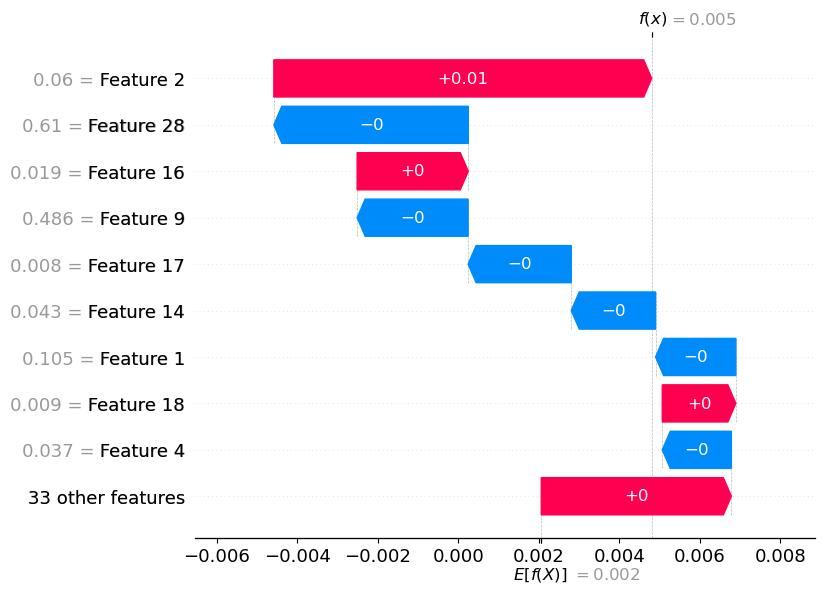

In [90]:
# shap.waterfall_plot(shap_values,X_test_subset)

# pick a random sample index
i = np.random.randint(0, len(X_test_subset))

# pass the single Explanation for that sample
shap.waterfall_plot(shap_values[i])

In [91]:
# Extract loss and validation loss from the training history
test_values = y_test*max(y)
pred_values = y_pred*max(y)

test_values = np.ravel(test_values)
pred_values = np.ravel(pred_values)

# Create a new DataFrame
pred_df = pd.DataFrame({
    'Test Values': test_values,
    'Predicted Values': pred_values
})

file_path =  '/global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/test_vs_pred_values.csv'

# Export to a CSV file
# pred_df.to_csv(file_path, index=False)

from sklearn.metrics import r2_score

# Assuming test_values and pred_values are 1D arrays or lists
r_squared = r2_score(test_values, pred_values)
print(f"R-squared value: {r_squared}")

R-squared value: 0.9182972094936946


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Compute MSE
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

# Extract loss and validation loss from the training history
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

# Create a new DataFrame
loss_df = pd.DataFrame({
    'Epoch': range(1, len(training_loss) + 1),  # Adding epoch numbers
    'Training Loss': training_loss,
    'Validation Loss': validation_loss
})

file_path =  '/global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/training_validation_losses.csv'

# Export to a CSV file
# loss_df.to_csv(file_path, index=False)

In [ ]:
# Plot y_test and y_pred as a time series
plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(y_test)), y_test*max(y), label="Actual Values (y_test)", color="blue", alpha=0.7)
plt.plot(np.arange(len(y_pred)), y_pred*max(y), label="Predicted Values (y_pred)", color="red", alpha=0.7)
plt.title("Actual vs Predicted Values of Test Dataset")
plt.xlabel("Test Dataset")
plt.ylabel("Streamflow [m${^3}$/s]")
plt.xlim(0,len(y_test))
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Plot y_test and y_pred as a time series
plt.figure(figsize=(12, 6))
plt.plot((np.arange(len(y_test)))[0:500], (y_test*max(y))[0:500], label="Actual Values (y_test)", color="blue", alpha=0.7)
plt.plot((np.arange(len(y_pred)))[0:500], (y_pred*max(y))[0:500], label="Predicted Values (y_pred)", color="red", alpha=0.7)

# Add titles and labels
plt.title("Actual vs Predicted Values of Test Dataset (element 0 to 500)")
plt.xlabel("Test Dataset")
plt.ylabel("Streamflow [m${^3}$/s]")
# plt.xlim(0,len(y_test))
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.scatter(scaled,q)
plt.title('Raw Data - All Basins')
plt.xlabel('Surface Water Extent Area [km${^2}$]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(area,q,color='g')
plt.title('Raw Data - All Basins')
plt.xlabel('Total Basin Area [km${^2}$]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(lat*np.pi/180,q,color='r')
plt.title('Raw Data - All Basins')
plt.xlabel('Latitude [deg]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(avg_slope,q,color='purple')
plt.title('Raw Data - All Basins')
plt.xlabel('Slope [deg]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(max_slope,q,color='brown')
plt.title('Raw Data - All Basins')
plt.xlabel('Slope [deg]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(precip/1e6,q,color='blue')
plt.title('Raw Data - All Basins')
plt.xlabel('Precip []')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
lc_class = lc_types.idxmax(axis=1)
plt.scatter(lc_class,q,color='orange')
plt.title('Raw Data - All Basins')
plt.xlabel('Land Cover Type')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
soil_class = soil_types.idxmax(axis=1)

plt.scatter(soil_class,q,color='darkorange')
plt.title('Raw Data - All Basins')
plt.xlabel('Soil Texture')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
grouped = total_df.groupby('Area')['Q'].mean()

# Extract unique areas and their corresponding average Q values
area_unique = grouped.index
q_avg = grouped.values

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(area_unique, q_avg, color='g')
plt.xlabel('Total Basin Area')
plt.ylabel('Average Streamflow')
plt.title('Average Streamflow vs Total Basin Area')
plt.grid(True)
plt.show()

In [ ]:
grouped = total_df.groupby('Latitude')['Q'].mean()

# Extract unique areas and their corresponding average Q values
lat_unique = grouped.index
q_avg = grouped.values

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(lat_unique, q_avg,color='red')
plt.xlabel('Latitude')
plt.ylabel('Average Streamflow')e
plt.title('Average Streamflow vs Basin Latitude')
plt.grid(True)
plt.show()

In [ ]:
filename = '/global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rnn_plot.png'
# Ensure the directory exists
os.makedirs(os.path.dirname(filename), exist_ok=True)
from tensorflow.keras.utils import plot_model

# Plot and save the model
plot_model(model,show_dtype=True, show_layer_names=True, show_shapes=True,  to_file=filename)

# # from IPython.display import Image
# # Image(filename)